# Этап 2. Разведочный анализ данных (EDA)

Цели:
- Базовая чистка (проверки, типизация, дубликаты — уже зафиксировано на Этапе 1).
- Анализ распределений ключевых атрибутов и их связей.
- Подготовка выводов для следующего этапа: схема SQLite и пайплайн загрузки.


1) Imports + настройки (Code)

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import sys
print(sys.executable)


!{sys.executable} -m pip install -q catboost

import catboost
print(sys.executable)
print(catboost.__version__)

!{sys.executable} -m pip install -q xgboost

import xgboost
xgboost.__version__




pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path("../data/raw")

SESS_PKL = DATA_DIR / "ga_sessions.pkl"
SESS_CSV = DATA_DIR / "ga_sessions.csv"
HITS_PKL = DATA_DIR / "ga_hits-003.pkl"
HITS_CSV = DATA_DIR / "ga_hits-001.csv"


2) Загрузка данных

In [3]:
def read_best(path_pkl: Path, path_csv: Path) -> pd.DataFrame:
    # Если есть pkl — читаем его (быстрее и типы сохраняются)
    if path_pkl.exists():
        return pd.read_pickle(path_pkl)
    # Иначе читаем csv
    return pd.read_csv(path_csv)

sessions = read_best(SESS_PKL, SESS_CSV)
hits = read_best(HITS_PKL, HITS_CSV)

print("sessions shape:", sessions.shape)
print("hits shape:", hits.shape)


sessions shape: (1860042, 18)
hits shape: (15726470, 11)


3) Мини-чистка для EDA

In [4]:
# Создаём clean-копии для EDA
sessions_clean = sessions.copy()
hits_clean = hits.copy()

# Даты
sessions_clean["visit_date"] = pd.to_datetime(sessions_clean["visit_date"], errors="coerce")
hits_clean["hit_date"] = pd.to_datetime(hits_clean["hit_date"], errors="coerce")

# Время
sessions_clean["visit_time"] = sessions_clean["visit_time"].astype("string").str.strip()
hits_clean["hit_time"] = pd.to_numeric(hits_clean["hit_time"], errors="coerce").astype("Int64")

# Порядковые номера
sessions_clean["visit_number"] = pd.to_numeric(sessions_clean["visit_number"], errors="coerce").astype("Int64")
hits_clean["hit_number"] = pd.to_numeric(hits_clean["hit_number"], errors="coerce").astype("Int64")

# Удаляем бесполезное поле (100% NULL)
if "event_value" in hits_clean.columns:
    hits_clean = hits_clean.drop(columns=["event_value"])

# Trim строк
for c in sessions_clean.select_dtypes(include=["object"]).columns:
    sessions_clean[c] = sessions_clean[c].astype("string").str.strip()

for c in hits_clean.select_dtypes(include=["object"]).columns:
    hits_clean[c] = hits_clean[c].astype("string").str.strip()

# Быстрый sanity check
print("visit_date min/max:", sessions_clean["visit_date"].min(), sessions_clean["visit_date"].max())
print("hit_date min/max:", hits_clean["hit_date"].min(), hits_clean["hit_date"].max())


visit_date min/max: 2021-05-19 00:00:00 2021-12-31 00:00:00
hit_date min/max: 2021-05-19 00:00:00 2021-12-31 00:00:00


Секция 1 EDA: базовые распределения (первый шаг)
4) Распределение устройств 

device_category
mobile     1474871
desktop     366863
tablet       18308
Name: count, dtype: Int64

device_browser
Chrome                              1013436
Safari                               478562
YaBrowser                            133311
Safari (in-app)                       69912
Android Webview                       55369
Samsung Internet                      47309
Opera                                 26817
Firefox                               16588
Edge                                  16065
UC Browser                              871
Android Runtime                         392
Mozilla Compatible Agent                362
[FBAN                                   269
Instagram 208.0.0.32.135 Android        140
Instagram 209.0.0.21.119 Android        111
Name: count, dtype: Int64

device_brand
Apple        551088
Samsung      332194
Xiaomi       288367
             248500
Huawei       185853
<NA>         118678
Realme        19058
(not set)     17545
OPPO          13504
Vivo          11740
OnePlus        9965
Asus           7929
Nokia          7285
Sony           6459
ZTE            6365
Name: count, dtype: Int64

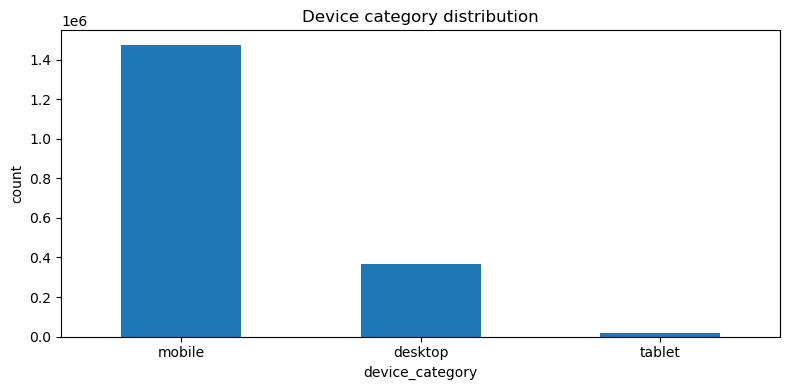

In [5]:
# Топ категорий устройств
display(sessions_clean["device_category"].value_counts(dropna=False))

# Топ браузеров
display(sessions_clean["device_browser"].value_counts(dropna=False).head(15))

# Топ брендов (с пропусками)
display(sessions_clean["device_brand"].value_counts(dropna=False).head(15))

# Частоты по категориям устройства
cat_counts = sessions_clean["device_category"].value_counts(dropna=False)

# Барчарт
plt.figure(figsize=(8, 4))
cat_counts.plot(kind="bar")
plt.title("Device category distribution")
plt.xlabel("device_category")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



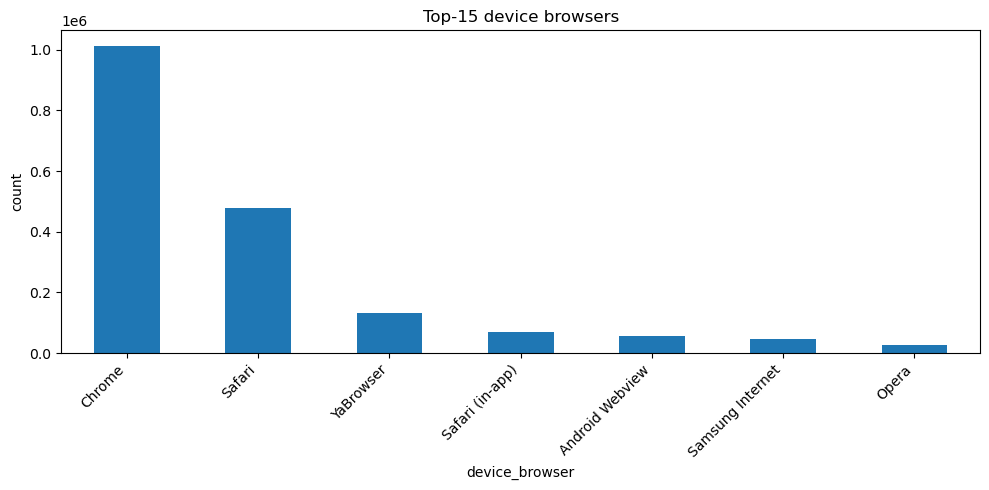

In [6]:
# Топ-15 браузеров
browser_counts = sessions_clean["device_browser"].value_counts(dropna=False).head(7)

plt.figure(figsize=(10, 5))
browser_counts.plot(kind="bar")
plt.title("Top-15 device browsers")
plt.xlabel("device_browser")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


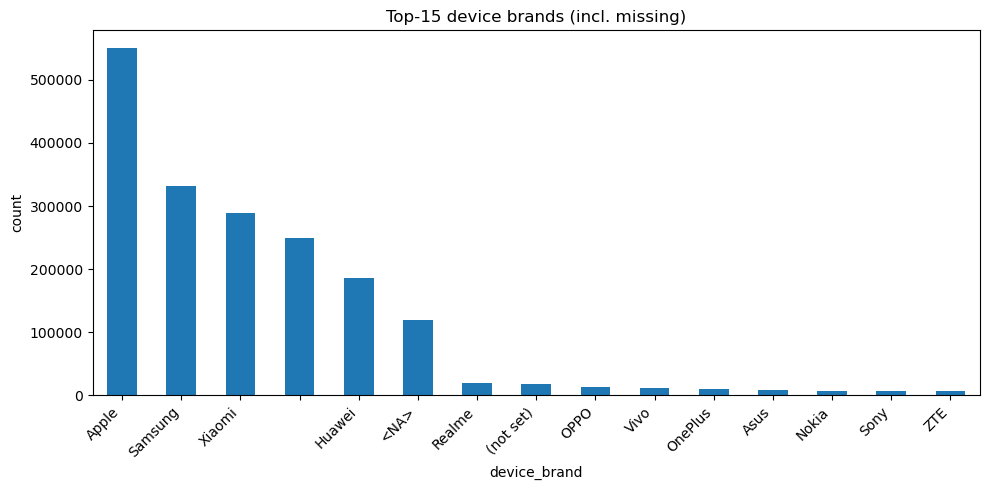

In [7]:
# Топ-15 брендов
brand_counts = sessions_clean["device_brand"].value_counts(dropna=False).head(15)

plt.figure(figsize=(10, 5))
brand_counts.plot(kind="bar")
plt.title("Top-15 device brands (incl. missing)")
plt.xlabel("device_brand")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


5) Проверка "аномалии" device_os

In [8]:
# Доля пропусков device_os в целом
os_missing_rate = sessions_clean["device_os"].isna().mean()
print("device_os missing rate:", round(os_missing_rate, 4))

# Доля пропусков device_os по device_category
os_missing_by_cat = (
    sessions_clean.assign(device_os_missing=sessions_clean["device_os"].isna())
    .groupby("device_category")["device_os_missing"]
    .mean()
    .sort_values(ascending=False)
)

display(os_missing_by_cat)


device_os missing rate: 0.5753


device_category
desktop    0.676610
tablet     0.635460
mobile     0.549391
Name: device_os_missing, dtype: float64

Секция: Device OS distribution (top-20) + доля пропусков

device_os missing rate: 0.5753


device_os
MISSING          1070138
Android           464054
iOS               207104
Windows            88307
Macintosh          24824
Linux               5120
(not set)            364
Chrome OS             83
BlackBerry            27
Tizen                  7
Samsung                4
Windows Phone          4
Firefox OS             3
Nokia                  3
Name: count, dtype: Int64

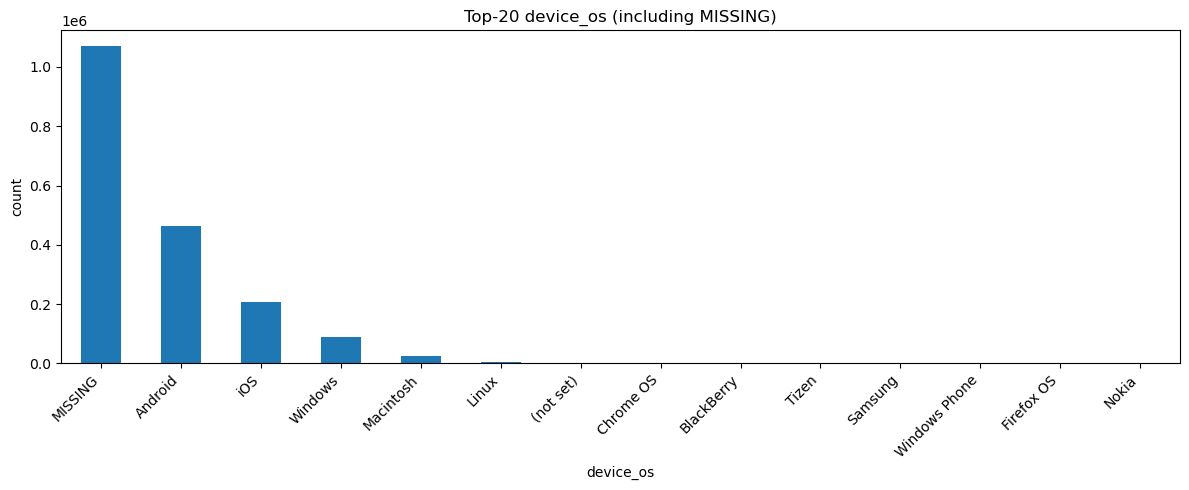

In [9]:


# --- 1) Доля пропусков device_os ---
os_missing_rate = sessions_clean["device_os"].isna().mean()
print("device_os missing rate:", round(os_missing_rate, 4))

# --- 2) Топ-20 значений device_os (включая пропуски как отдельную категорию) ---
# Заполним NaN строкой "MISSING" только для визуализации (данные не портим)
os_for_plot = sessions_clean["device_os"].fillna("MISSING")

os_counts = os_for_plot.value_counts().head(20)
display(os_counts)

plt.figure(figsize=(12, 5))
os_counts.plot(kind="bar")
plt.title("Top-20 device_os (including MISSING)")
plt.xlabel("device_os")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


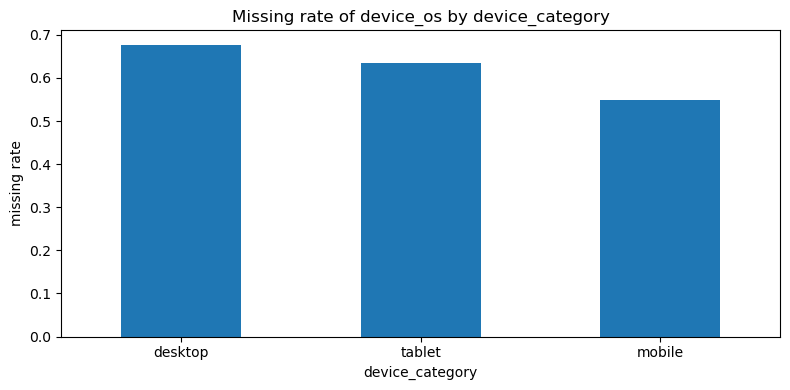

In [10]:
# Доля пропусков OS по категориям устройства
os_missing_by_cat = (
    sessions_clean.assign(device_os_missing=sessions_clean["device_os"].isna())
    .groupby("device_category")["device_os_missing"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
os_missing_by_cat.plot(kind="bar")
plt.title("Missing rate of device_os by device_category")
plt.xlabel("device_category")
plt.ylabel("missing rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


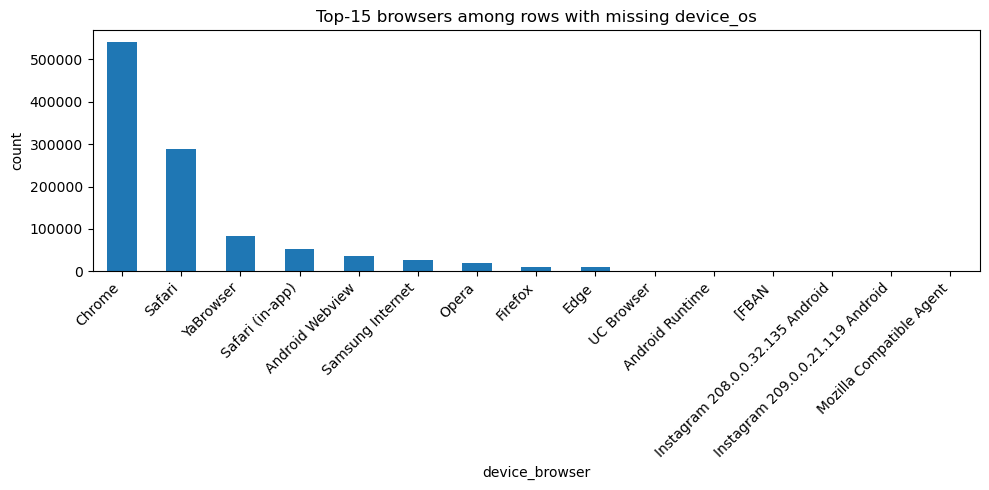

In [11]:
# Строки без device_os
no_os = sessions_clean[sessions_clean["device_os"].isna()]

# Топ-15 браузеров среди no_os
no_os_browsers = no_os["device_browser"].value_counts(dropna=False).head(15)

plt.figure(figsize=(10, 5))
no_os_browsers.plot(kind="bar")
plt.title("Top-15 browsers among rows with missing device_os")
plt.xlabel("device_browser")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Секция 2: Geo (top-20)

geo_country
Russia            1800565
United States       11784
Ukraine              9012
Ireland              4034
Belarus              3636
Sweden               2694
Kazakhstan           2279
Germany              2232
Turkey               1953
Netherlands          1549
Uzbekistan           1523
United Kingdom       1462
(not set)            1146
Kyrgyzstan            974
Georgia               935
France                790
Cyprus                765
Armenia               681
Finland               643
Spain                 599
Name: count, dtype: Int64

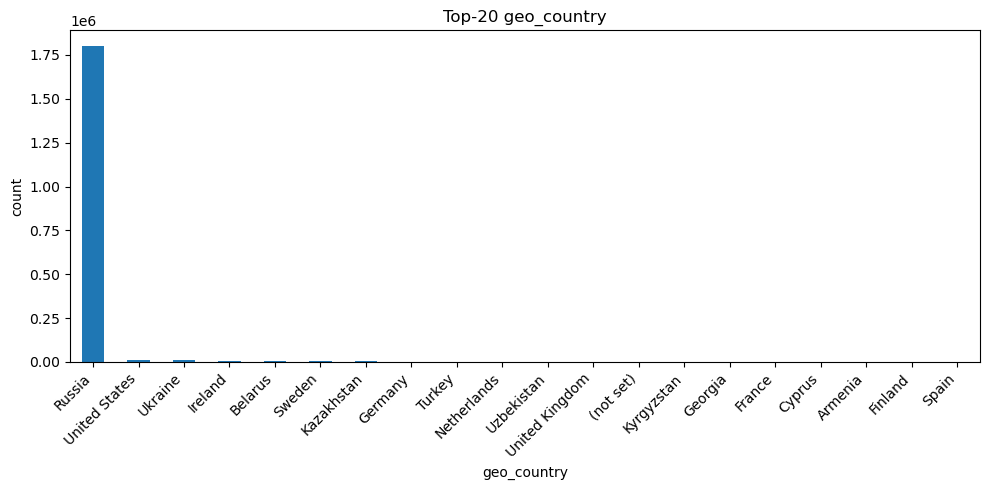

In [12]:
import matplotlib.pyplot as plt

# --- Geo: country (top-20) ---
country_counts = sessions_clean["geo_country"].value_counts(dropna=False).head(20)
display(country_counts)

plt.figure(figsize=(10, 5))
country_counts.plot(kind="bar")
plt.title("Top-20 geo_country")
plt.xlabel("geo_country")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


geo_city
Moscow              805329
Saint Petersburg    296788
(not set)            78172
Yekaterinburg        35788
Krasnodar            32243
Kazan                29531
Samara               24992
Nizhny Novgorod      22227
Ufa                  21679
Novosibirsk          21568
Krasnoyarsk          16346
Chelyabinsk          15951
Tula                 15814
Voronezh             13908
Rostov-on-Don        13886
Irkutsk              13532
Grozny               12742
Balashikha           12679
Vladivostok          12325
Yaroslavl             9833
Name: count, dtype: Int64

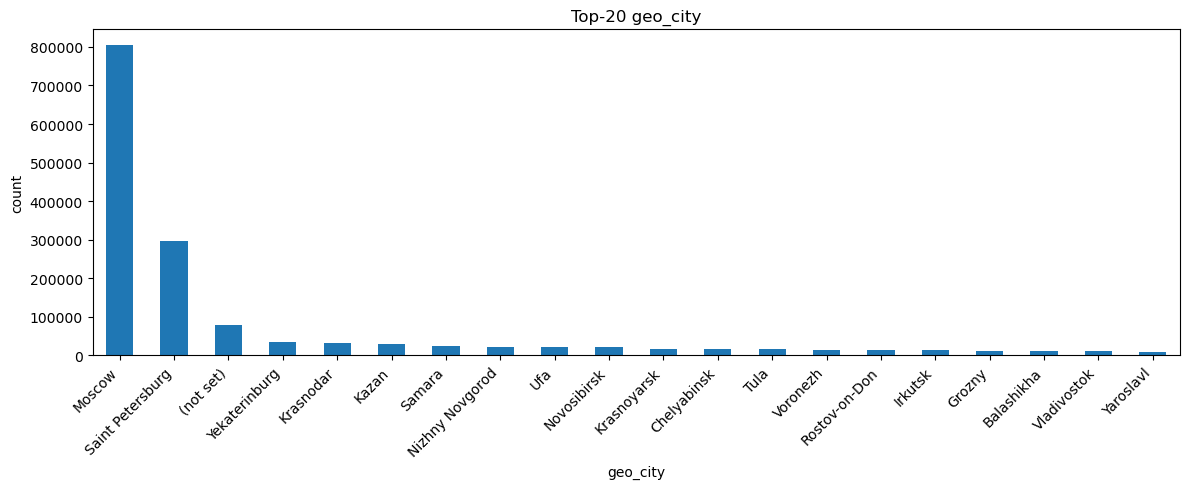

In [13]:
# --- Geo: city (top-20) ---
city_counts = sessions_clean["geo_city"].value_counts(dropna=False).head(20)
display(city_counts)

plt.figure(figsize=(12, 5))
city_counts.plot(kind="bar")
plt.title("Top-20 geo_city")
plt.xlabel("geo_city")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Секция 3: UTM / Marketing (top-20)

utm_source
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
bByPQxmDaMXgpHeypKSM    102287
QxAxdyPLuQMEcrdZWdWb     51415
aXQzDWsJuGXeBXexNHjc     31152
jaSOmLICuBzCFqHfBdRg     29241
RmEBuqrriAfAVsLQQmhk     28055
vFcAhRxLfOWKhvxjELkx     24413
PlbkrSYoHuZBWfYjYnfw     20792
hTjLvqNxGggkGnxSCaTm     14598
gDBGzjFKYabGgSPZvrDH     13565
fgymSoTvjKPEgaIJqsiH      9625
geDcueAOghDzHkGMmdOq      8680
ISrKoXQCxqqYvAZICvjs      8633
nSReTmyFtbSjlPrTKoaX      7285
SzZERoLMmrEUEhDaYcyN      6828
eLzNJHzPelJpEyBwMrKo      5386
Name: count, dtype: Int64

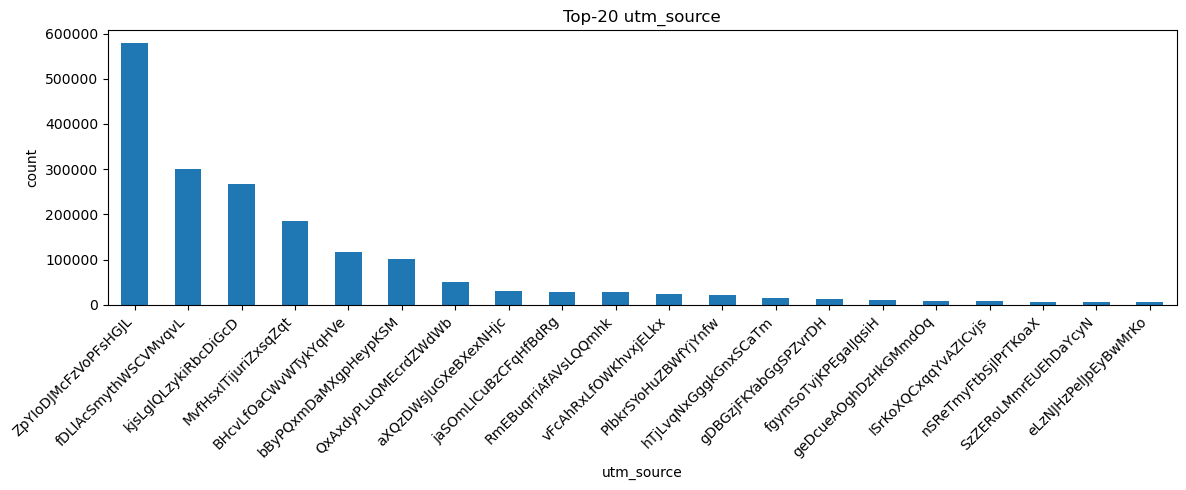

In [14]:
# --- UTM: source (top-20) ---
utm_source_counts = sessions_clean["utm_source"].value_counts(dropna=False).head(20)
display(utm_source_counts)

plt.figure(figsize=(12, 5))
utm_source_counts.plot(kind="bar")
plt.title("Top-20 utm_source")
plt.xlabel("utm_source")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


utm_medium
banner             552272
cpc                434794
(none)             300575
cpm                242083
referral           152050
organic             63034
email               29240
push                28035
stories             10582
cpv                  8022
blogger_channel      8015
smartbanner          6794
blogger_stories      4312
cpa                  4279
tg                   4011
app                  2836
post                 2326
smm                  1985
outlook              1332
clicks                934
Name: count, dtype: Int64

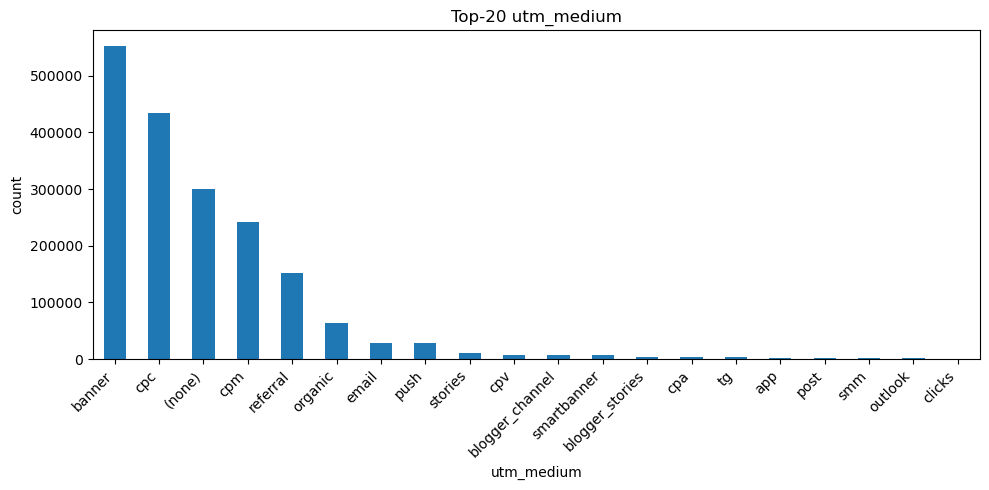

In [15]:
# --- UTM: medium (top-20) ---
utm_medium_counts = sessions_clean["utm_medium"].value_counts(dropna=False).head(20)
display(utm_medium_counts)

plt.figure(figsize=(10, 5))
utm_medium_counts.plot(kind="bar")
plt.title("Top-20 utm_medium")
plt.xlabel("utm_medium")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Секция 4: Hits & Events (top-20)
4.1 Типы hit’ов

hit_type
event    15726470
Name: count, dtype: Int64

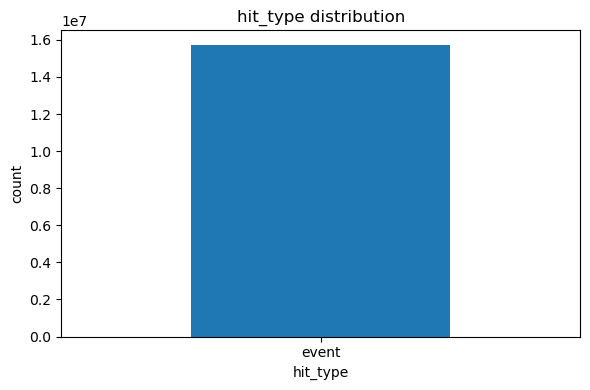

In [16]:
# --- hit_type distribution ---
hit_type_counts = hits_clean["hit_type"].value_counts(dropna=False)
display(hit_type_counts)

plt.figure(figsize=(6, 4))
hit_type_counts.plot(kind="bar")
plt.title("hit_type distribution")
plt.xlabel("hit_type")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


4.2 Топ-20 категорий событий

event_category
card_web                     7456998
search_form                  2423605
sub_page_view                1986074
sub_button_click             1073471
listing_ads                  1040468
cars                          358915
sap_search_form               356596
quiz                          263134
auth                          189373
sap_search__form              188129
jivosite                       88443
chat                           85007
ad_banner                      40441
offers                         31218
navigation                     27075
footer                         20297
sub_submit                     18495
greenday_sub_button_click      15425
main_banners                   14142
profile_menu                   13879
Name: count, dtype: Int64

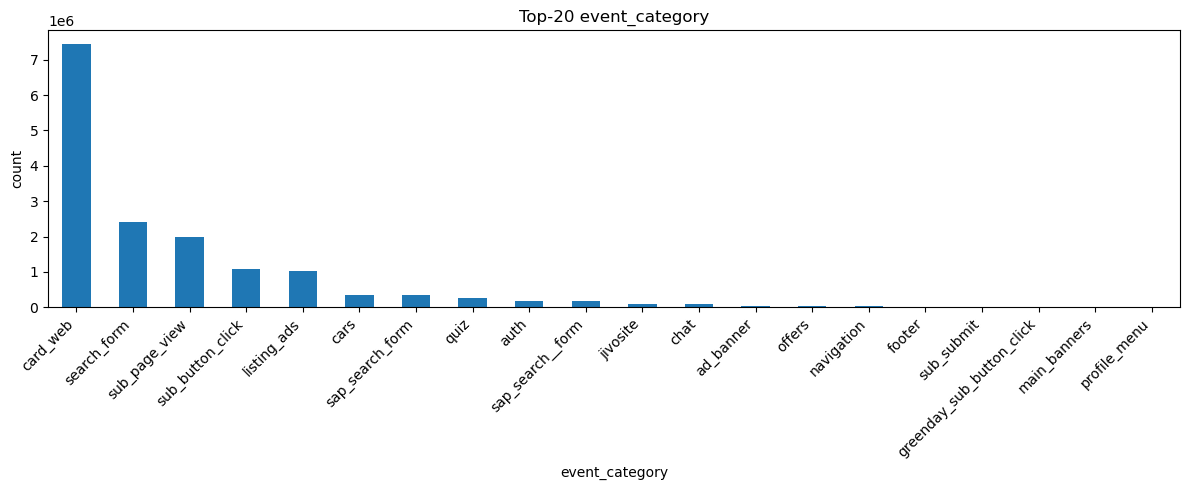

In [17]:
# --- event_category (top-20) ---
event_cat_counts = hits_clean["event_category"].value_counts(dropna=False).head(20)
display(event_cat_counts)

plt.figure(figsize=(12, 5))
event_cat_counts.plot(kind="bar")
plt.title("Top-20 event_category")
plt.xlabel("event_category")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


4.3 Топ-20 действий событий

event_action
view_card                             3558985
view_new_card                         3551009
sub_landing                           1798117
go_to_car_card                         973666
sub_view_cars_click                    791515
search_form_region                     512069
search_form_search_btn                 433748
sap_search_form_cost_to                356596
showed_number_ads                      326274
pagination_click                       248944
search_form_mark_select                222652
quiz_show                              214037
search_form_model_select               211890
sap_search_form_cost_from              188129
photos_all                             181493
search_form_search_car_type_select     174877
photos                                 158543
sub_car_page                           130310
view_more_click                        109971
search_kpp                              79465
Name: count, dtype: Int64

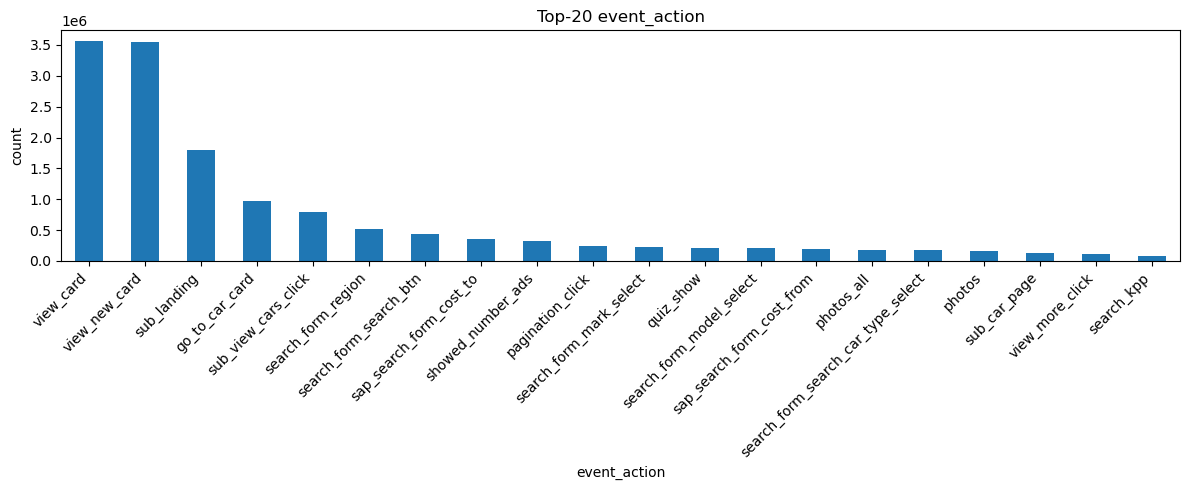

In [18]:
# --- event_action (top-20) ---
event_action_counts = hits_clean["event_action"].value_counts(dropna=False).head(20)
display(event_action_counts)

plt.figure(figsize=(12, 5))
event_action_counts.plot(kind="bar")
plt.title("Top-20 event_action")
plt.xlabel("event_action")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [19]:


# --- 1) Определяем "конверсионное" действие ---
CONV_ACTION = "showed_number_ads"  # можно поменять на другое позже

# --- 2) Флаг: есть ли это действие в сессии ---
# Создаём таблицу session_id -> conv_flag (1/0)
conv_sessions = (
    hits_clean.assign(is_conv=(hits_clean["event_action"] == CONV_ACTION))
    .groupby("session_id")["is_conv"]
    .any()                     # True если хотя бы 1 раз случилось в сессии
    .astype("int")             # переведём в 0/1 для удобства
    .rename("conv_flag")
    .reset_index()
)

# --- 3) Присоединяем к sessions_clean ---
sessions_conv = sessions_clean.merge(conv_sessions, on="session_id", how="left")

# Сессии без записей в hits (если вдруг такие есть) считаем как 0
sessions_conv["conv_flag"] = sessions_conv["conv_flag"].fillna(0).astype("int")

# Быстрая проверка общей конверсии
overall_conv_rate = sessions_conv["conv_flag"].mean()
print("Overall conversion rate (session has action):", round(overall_conv_rate, 4))
print("Converted sessions:", int(sessions_conv["conv_flag"].sum()), "out of", len(sessions_conv))


Overall conversion rate (session has action): 0.0626
Converted sessions: 116396 out of 1860042


In [20]:
# --- 4) Конверсия по utm_medium ---
# conversion rate = доля сессий, где conv_flag=1
conv_by_medium = (
    sessions_conv.groupby("utm_medium")["conv_flag"]
    .agg(conv_rate="mean", sessions="size", conversions="sum")
    .sort_values("sessions", ascending=False)
)

# Для читабельности покажем top-20 medium по числу сессий
display(conv_by_medium.head(20))


,conv_rate,sessions,conversions
utm_medium,,,
banner,0.123729,552272,68332
cpc,0.033837,434794,14712
(none),0.034896,300575,10489
cpm,0.014978,242083,3626
referral,0.036606,152050,5566
organic,0.073468,63034,4631
email,0.067202,29240,1965
push,0.191653,28035,5373
stories,0.000095,10582,1


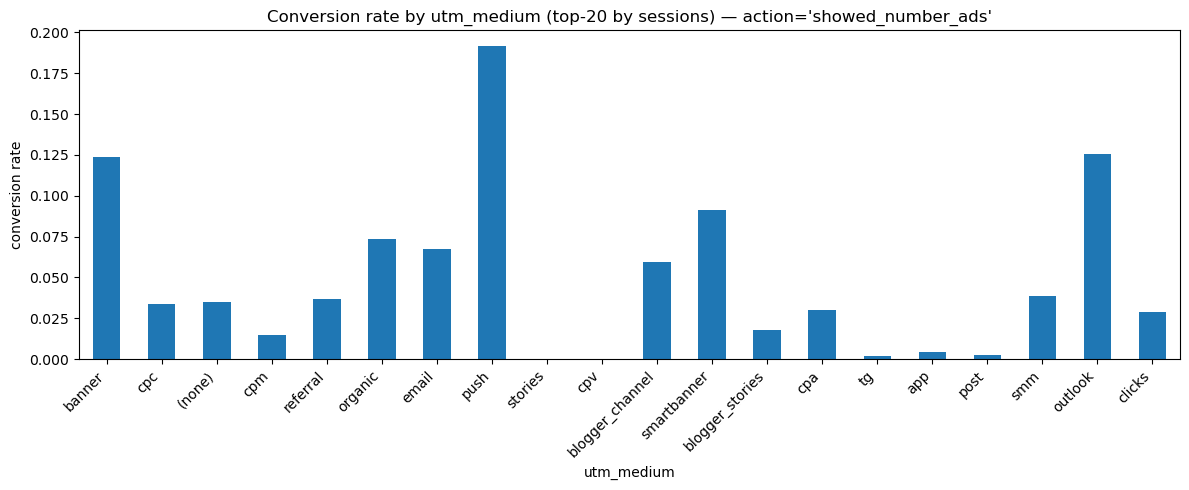

In [21]:
# --- 5) График: конверсия по utm_medium (top-20 по объёму) ---
top20 = conv_by_medium.head(20).copy()

plt.figure(figsize=(12, 5))
top20["conv_rate"].plot(kind="bar")
plt.title(f"Conversion rate by utm_medium (top-20 by sessions) — action='{CONV_ACTION}'")
plt.xlabel("utm_medium")
plt.ylabel("conversion rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [22]:
# --- 6) Фильтр по минимальному числу сессий (например, >= 1000) ---
min_sessions = 1000

conv_by_medium_filtered = conv_by_medium[conv_by_medium["sessions"] >= min_sessions] \
    .sort_values("conv_rate", ascending=False)

display(conv_by_medium_filtered.head(20))


,conv_rate,sessions,conversions
utm_medium,,,
push,0.191653,28035,5373
outlook,0.125375,1332,167
banner,0.123729,552272,68332
smartbanner,0.091110,6794,619
organic,0.073468,63034,4631
email,0.067202,29240,1965
blogger_channel,0.059389,8015,476
smm,0.038791,1985,77
referral,0.036606,152050,5566


Мини-метрики связи sessions ↔ hits (очень полезно для выводов)

hits per session: mean = 9.07
hits per session: median = 4.0
hits per session: 95% quantile = 34.0


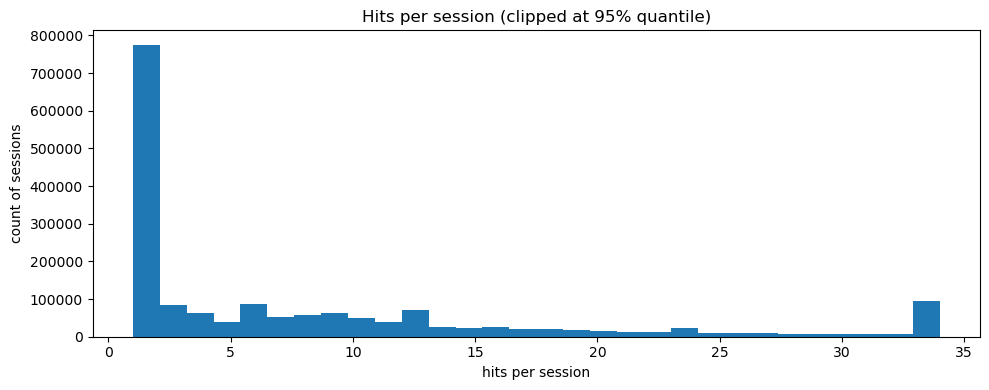

In [23]:
# Считаем количество hit-строк на одну сессию
hits_per_session = hits_clean.groupby("session_id").size()

print("hits per session: mean =", round(hits_per_session.mean(), 2))
print("hits per session: median =", round(hits_per_session.median(), 2))
print("hits per session: 95% quantile =", round(hits_per_session.quantile(0.95), 2))

# Гистограмма (обрежем хвост по 95% квантилю, чтобы было читабельно)
cap = hits_per_session.quantile(0.95)
plt.figure(figsize=(10, 4))
hits_per_session.clip(upper=cap).plot(kind="hist", bins=30)
plt.title("Hits per session (clipped at 95% quantile)")
plt.xlabel("hits per session")
plt.ylabel("count of sessions")
plt.tight_layout()
plt.show()


In [24]:
# --- Список "конверсий" (event_action) ---
CONV_ACTIONS = ["showed_number_ads", "go_to_car_card", "quiz_show"]

# --- Сессия -> флаги конверсий ---
# Для каждой сессии считаем, было ли хотя бы одно событие каждого типа
conv_flags = (
    hits_clean[hits_clean["event_action"].isin(CONV_ACTIONS)]
    .assign(flag=1)
    .pivot_table(
        index="session_id",
        columns="event_action",
        values="flag",
        aggfunc="max",   # если встречалось — будет 1
        fill_value=0
    )
    .reset_index()
)

# Переименуем колонки в conv_<action> для читаемости
rename_map = {a: f"conv_{a}" for a in CONV_ACTIONS}
conv_flags = conv_flags.rename(columns=rename_map)

# --- Объединяем с sessions_clean ---
sessions_multi = sessions_clean.merge(conv_flags, on="session_id", how="left")

# Сессии без этих событий -> 0
for a in CONV_ACTIONS:
    col = f"conv_{a}"
    if col not in sessions_multi.columns:
        sessions_multi[col] = 0
    sessions_multi[col] = sessions_multi[col].fillna(0).astype("int")

# Быстрый общий уровень по каждой конверсии
overall_rates = {a: sessions_multi[f"conv_{a}"].mean() for a in CONV_ACTIONS}
overall_rates


{'showed_number_ads': 0.06257708159278123,
 'go_to_car_card': 0.2714411825109325,
 'quiz_show': 0.09032376688268329}

In [25]:
# Считаем по utm_medium: размер, и долю конверсии по каждому действию
agg_dict = {"session_id": "size"}
for a in CONV_ACTIONS:
    agg_dict[f"conv_{a}"] = "mean"

conv_by_medium_multi = (
    sessions_multi.groupby("utm_medium")
    .agg(agg_dict)
    .rename(columns={"session_id": "sessions"})
    .sort_values("sessions", ascending=False)
)

# Выведем top-20 по объёму
display(conv_by_medium_multi.head(20))


,sessions,conv_showed_number_ads,conv_go_to_car_card,conv_quiz_show
utm_medium,,,,
banner,552272,0.123729,0.306186,0.065504
cpc,434794,0.033837,0.252099,0.101501
(none),300575,0.034896,0.342221,0.161953
cpm,242083,0.014978,0.076003,0.022868
referral,152050,0.036606,0.355041,0.110602
organic,63034,0.073468,0.327046,0.089476
email,29240,0.067202,0.268570,0.139364
push,28035,0.191653,0.242340,0.046763
stories,10582,0.000095,0.296636,0.126158


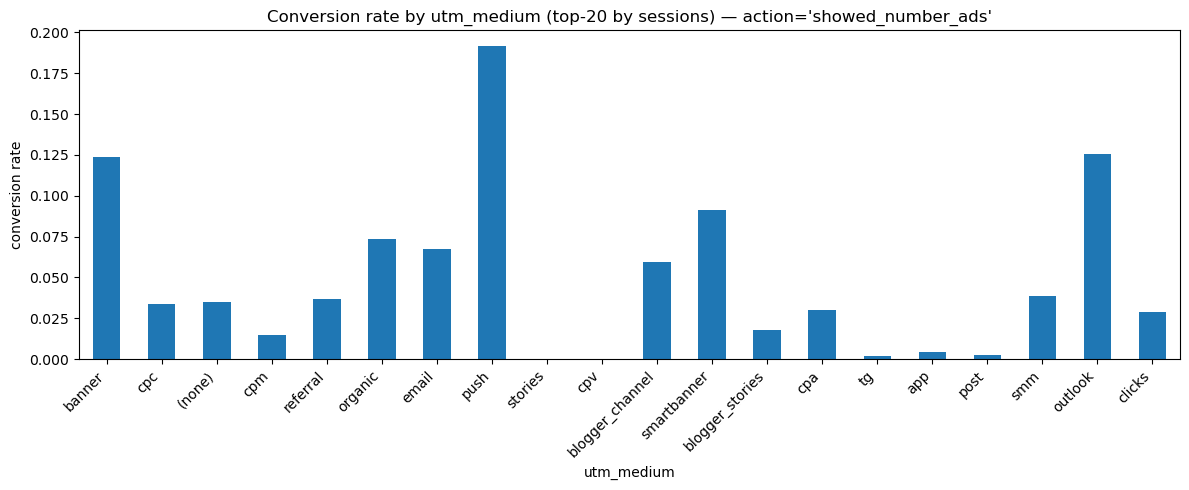

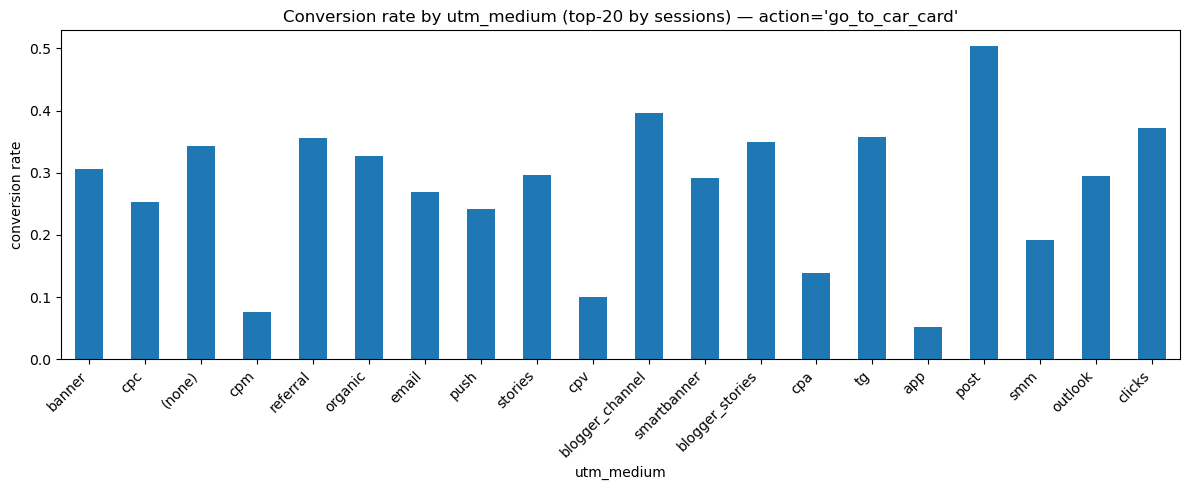

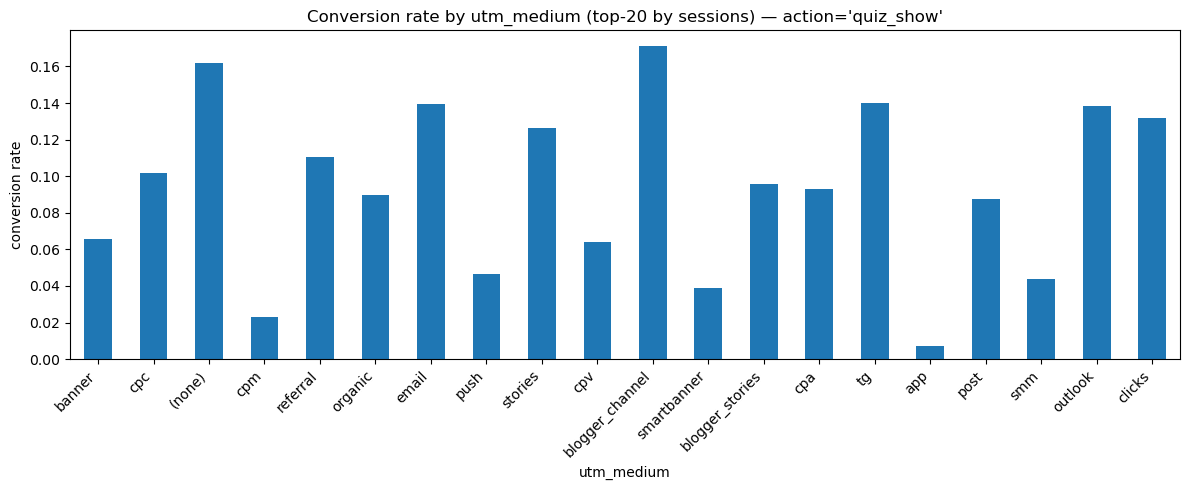

In [26]:
top20 = conv_by_medium_multi.head(20)

for a in CONV_ACTIONS:
    col = f"conv_{a}"
    plt.figure(figsize=(12, 5))
    top20[col].plot(kind="bar")
    plt.title(f"Conversion rate by utm_medium (top-20 by sessions) — action='{a}'")
    plt.xlabel("utm_medium")
    plt.ylabel("conversion rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Overall rate (all 3 actions in a session): 0.0049


,sessions,all3_rate
utm_medium,,
banner,552272,0.005691
cpc,434794,0.004703
(none),300575,0.005446
cpm,242083,0.001950
referral,152050,0.004281
organic,63034,0.010010
email,29240,0.006361
push,28035,0.009988
stories,10582,0.000000


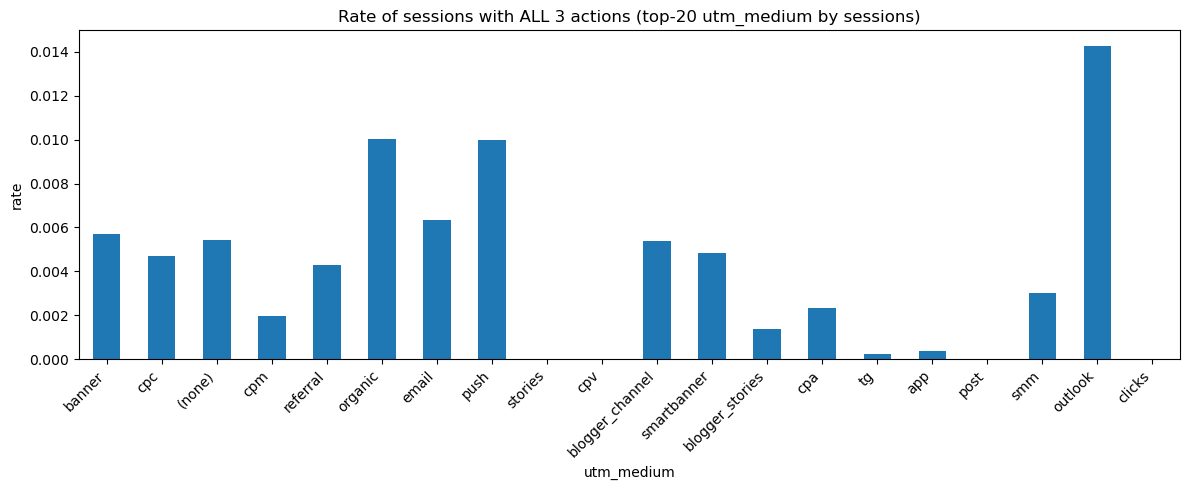

In [27]:
# Флаг: случились все три действия в рамках одной сессии
sessions_multi["conv_all_3"] = (
    sessions_multi[[f"conv_{a}" for a in CONV_ACTIONS]].min(axis=1)
)

print("Overall rate (all 3 actions in a session):", round(sessions_multi["conv_all_3"].mean(), 4))

funnel_by_medium = (
    sessions_multi.groupby("utm_medium")
    .agg(
        sessions=("session_id", "size"),
        all3_rate=("conv_all_3", "mean")
    )
    .sort_values("sessions", ascending=False)
)

display(funnel_by_medium.head(20))

plt.figure(figsize=(12, 5))
funnel_by_medium.head(20)["all3_rate"].plot(kind="bar")
plt.title("Rate of sessions with ALL 3 actions (top-20 utm_medium by sessions)")
plt.xlabel("utm_medium")
plt.ylabel("rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [28]:
# === Build session-level features for EDA (from sessions_clean + hits_clean) ===

# 1) Агрегаты по hits на уровень session_id
hits_agg = (
    hits_clean
    .groupby("session_id", dropna=False)
    .agg(
        hits_cnt=("hit_number", "count"),
        uniq_actions_cnt=("event_action", pd.Series.nunique),
        has_go_to_car_card=("event_action", lambda s: int((s == "go_to_car_card").any())),
        has_showed_number_ads=("event_action", lambda s: int((s == "showed_number_ads").any())),
        has_quiz_show=("event_action", lambda s: int((s == "quiz_show").any())),
    )
    .reset_index()
)

# 2) Джойним к sessions_clean (уровень сессии)
session_features_eda = sessions_clean.merge(hits_agg, on="session_id", how="left")

# 3) Заполняем нули там, где сессии без хитов
for c in ["hits_cnt", "uniq_actions_cnt", "has_go_to_car_card", "has_showed_number_ads", "has_quiz_show"]:
    session_features_eda[c] = session_features_eda[c].fillna(0).astype(int)

session_features_eda.shape, session_features_eda.columns.tolist()


((1860042, 23),
 ['session_id',
  'client_id',
  'visit_date',
  'visit_time',
  'visit_number',
  'utm_source',
  'utm_medium',
  'utm_campaign',
  'utm_adcontent',
  'utm_keyword',
  'device_category',
  'device_os',
  'device_brand',
  'device_model',
  'device_screen_resolution',
  'device_browser',
  'geo_country',
  'geo_city',
  'hits_cnt',
  'uniq_actions_cnt',
  'has_go_to_car_card',
  'has_showed_number_ads',
  'has_quiz_show'])

In [29]:
# === Targets for EDA (mirror your project definitions) ===

# MAIN target: был showed_number_ads в сессии
session_features_eda["target_showed_number_ads"] = session_features_eda["has_showed_number_ads"].astype(int)

# SECONDARY target: go_to_car_card -> showed_number_ads (проверяем порядок по hit_number)
# Делаем аккуратно: берём min(hit_number) для каждого action в рамках сессии
tmp = hits_clean[hits_clean["event_action"].isin(["go_to_car_card", "showed_number_ads"])].copy()
tmp["hit_number_num"] = pd.to_numeric(tmp["hit_number"], errors="coerce")

first_hits = (
    tmp.groupby(["session_id", "event_action"], dropna=False)["hit_number_num"]
    .min()
    .unstack("event_action")
)

# funnel = go_to exists and showed exists and go_to happens earlier
funnel = (
    first_hits["go_to_car_card"].notna()
    & first_hits["showed_number_ads"].notna()
    & (first_hits["go_to_car_card"] < first_hits["showed_number_ads"])
).astype(int)

session_features_eda = session_features_eda.merge(
    funnel.rename("target_funnel_go_to_then_showed"),
    on="session_id",
    how="left",
)
session_features_eda["target_funnel_go_to_then_showed"] = session_features_eda["target_funnel_go_to_then_showed"].fillna(0).astype(int)

# === Correlation matrix for NUMERIC columns ===
num_df = session_features_eda.select_dtypes(include=[np.number]).copy()

# drop constant cols
num_df = num_df.loc[:, num_df.nunique(dropna=False) > 1]

corr = num_df.corr(numeric_only=True)
corr


,visit_number,hits_cnt,uniq_actions_cnt,has_go_to_car_card,has_showed_number_ads,has_quiz_show,target_showed_number_ads,target_funnel_go_to_then_showed
visit_number,1.000000,-0.000832,-0.013854,0.007136,-0.004976,-0.028916,-0.004976,0.001257
hits_cnt,-0.000832,1.000000,0.769494,0.539032,0.289818,0.297794,0.289818,0.159036
uniq_actions_cnt,-0.013854,0.769494,1.000000,0.638493,0.402173,0.338524,0.402173,0.170153
has_go_to_car_card,0.007136,0.539032,0.638493,1.000000,0.107599,0.222950,0.107599,0.117848
has_showed_number_ads,-0.004976,0.289818,0.402173,0.107599,1.000000,0.013727,1.000000,0.278413
has_quiz_show,-0.028916,0.297794,0.338524,0.222950,0.013727,1.000000,0.013727,0.028938
target_showed_number_ads,-0.004976,0.289818,0.402173,0.107599,1.000000,0.013727,1.000000,0.278413
target_funnel_go_to_then_showed,0.001257,0.159036,0.170153,0.117848,0.278413,0.028938,0.278413,1.000000


has_showed_number_ads              1.000000
uniq_actions_cnt                   0.402173
hits_cnt                           0.289818
target_funnel_go_to_then_showed    0.278413
has_go_to_car_card                 0.107599
has_quiz_show                      0.013727
visit_number                      -0.004976
Name: target_showed_number_ads, dtype: float64

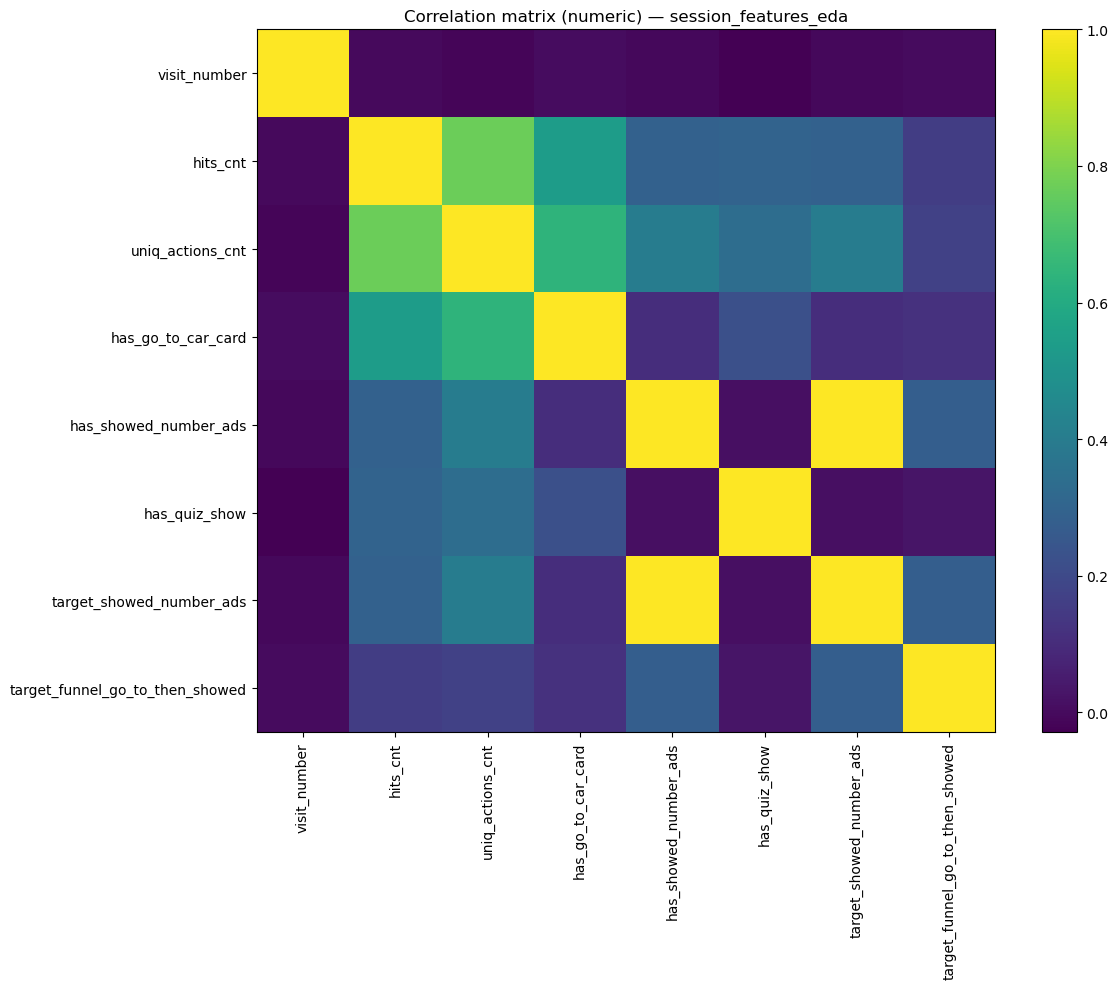

In [30]:
# === Heatmap + top correlations with target ===
TARGET = "target_showed_number_ads"  # можно поменять на "target_funnel_go_to_then_showed"

# Top correlations
if TARGET in corr.columns:
    corr_target = (
        corr[TARGET]
        .drop(labels=[TARGET])
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    display(corr_target.head(30))
else:
    print(f"Target '{TARGET}' not found among numeric columns.")

# Heatmap (matplotlib)
plt.figure(figsize=(12, 10))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title(f"Correlation matrix (numeric) — session_features_eda")
plt.colorbar()
plt.tight_layout()
plt.show()


In [31]:
# === Baseline PR-AUC: 2 numeric features vs LogisticRegression (leak-free) ===
# Что считаем:
# 1) "Супер простой" скорер на двух числовых фичах: uniq_actions_cnt + hits_cnt (через LogisticRegression)
# 2) LogisticRegression на всех фичах (categorical + numeric), но без ликажа (убираем has_showed_number_ads и оба таргета)
# Сплит: time-based по visit_date (как в проекте), чтобы не было ликажа по времени.

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

TARGET = "target_showed_number_ads"
TIME_COL = "visit_date"
TEST_SIZE = 0.2

df = session_features_eda.copy()

# аккуратно приводим дату
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

split_idx = int(len(df) * (1 - TEST_SIZE))
train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()

y_train = train_df[TARGET].astype(int).values
y_valid = valid_df[TARGET].astype(int).values

print("Train:", train_df.shape, "Valid:", valid_df.shape)
print("Pos rate train:", y_train.mean(), "valid:", y_valid.mean())


Train: (1488033, 25) Valid: (372009, 25)
Pos rate train: 0.03336821159208163 valid: 0.17941232604587523


In [32]:
# --- 1) Baseline: only two numeric features ---
two_feats = ["uniq_actions_cnt", "hits_cnt"]

X_train_2 = train_df[two_feats]
X_valid_2 = valid_df[two_feats]

pipe_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
])

pipe_2.fit(X_train_2, y_train)
proba_2 = pipe_2.predict_proba(X_valid_2)[:, 1]

pr_auc_2 = average_precision_score(y_valid, proba_2)
roc_auc_2 = roc_auc_score(y_valid, proba_2)

print(f"[2 features] PR-AUC: {pr_auc_2:.5f} | ROC-AUC: {roc_auc_2:.5f}")


[2 features] PR-AUC: 0.74299 | ROC-AUC: 0.93631


In [33]:
# --- 2) LogisticRegression on ALL features (leak-free) ---
# убираем явный ликаж и таргеты
drop_cols = [
    "has_showed_number_ads",                 # 100% = target
    "target_showed_number_ads",
    "target_funnel_go_to_then_showed",
]

X_train_all = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
X_valid_all = valid_df.drop(columns=[c for c in drop_cols if c in valid_df.columns])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), make_column_selector(dtype_include=np.number)),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), make_column_selector(dtype_include=object)),
    ],
    remainder="drop",
)

pipe_all = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
])

pipe_all.fit(X_train_all, y_train)
proba_all = pipe_all.predict_proba(X_valid_all)[:, 1]

pr_auc_all = average_precision_score(y_valid, proba_all)
roc_auc_all = roc_auc_score(y_valid, proba_all)

print(f"[All features leak-free] PR-AUC: {pr_auc_all:.5f} | ROC-AUC: {roc_auc_all:.5f}")


[All features leak-free] PR-AUC: 0.81107 | ROC-AUC: 0.95634


In [34]:
# (опционально) сравнение в одной табличке
pd.DataFrame(
    [
        {"model": "LogReg (2 features: uniq_actions_cnt + hits_cnt)", "pr_auc": pr_auc_2, "roc_auc": roc_auc_2},
        {"model": "LogReg (all features, leak-free)", "pr_auc": pr_auc_all, "roc_auc": roc_auc_all},
    ]
).sort_values("pr_auc", ascending=False)


,model,pr_auc,roc_auc
1,"LogReg (all features, leak-free)",0.811068,0.956338
0,LogReg (2 features: uniq_actions_cnt + hits_cnt),0.742988,0.936315


In [35]:
tmp = session_features_eda.copy()
tmp["visit_date"] = pd.to_datetime(tmp["visit_date"])
tmp = tmp.dropna(subset=["visit_date"])
tmp["month"] = tmp["visit_date"].dt.to_period("M").astype(str)

tmp.groupby("month")["target_showed_number_ads"].agg(["count","mean"]).rename(columns={"mean":"cr"})


,count,cr
month,,
2021-05,108202,0.000000
2021-06,166470,0.000000
2021-07,185244,0.000000
2021-08,164155,0.000000
2021-09,257478,0.000000
2021-10,281622,0.048420
2021-11,297769,0.109686
2021-12,399102,0.175642


In [36]:
tmp = hits_clean[hits_clean["event_action"] == "showed_number_ads"].copy()
tmp["hit_date"] = pd.to_datetime(tmp["hit_date"], errors="coerce")
tmp["month"] = tmp["hit_date"].dt.to_period("M").astype(str)

tmp.groupby("month").size().to_frame("showed_number_ads_hits")


,showed_number_ads_hits
month,
2021-10,46812
2021-11,88749
2021-12,190713


In [37]:
# === Volume before Oct 2021 vs from Oct 2021 (sessions + hits + conversions) ===
# Используем уже загруженные sessions_clean, hits_clean (и при желании session_features_eda)
# Цель: понять долю данных/событий до 2021-10-01 и после — и насколько “репрезентативен” период с таргетом.

import pandas as pd

CUT = pd.Timestamp("2021-10-01")

# --- Sessions volumes ---
sess = sessions_clean.dropna(subset=["visit_date"]).copy()

sess_before = sess[sess["visit_date"] < CUT]
sess_after  = sess[sess["visit_date"] >= CUT]

def pct(part, total):
    return 100.0 * part / total if total else 0.0

print("=== SESSIONS ===")
print(f"Total sessions: {len(sess):,}")
print(f"Before {CUT.date()}: {len(sess_before):,} ({pct(len(sess_before), len(sess)):.2f}%)")
print(f"From  {CUT.date()}: {len(sess_after):,} ({pct(len(sess_after), len(sess)):.2f}%)")

# --- Hits volumes ---
hits = hits_clean.dropna(subset=["hit_date"]).copy()

hits_before = hits[hits["hit_date"] < CUT]
hits_after  = hits[hits["hit_date"] >= CUT]

print("\n=== HITS ===")
print(f"Total hits: {len(hits):,}")
print(f"Before {CUT.date()}: {len(hits_before):,} ({pct(len(hits_before), len(hits)):.2f}%)")
print(f"From  {CUT.date()}: {len(hits_after):,} ({pct(len(hits_after), len(hits)):.2f}%)")

# --- showed_number_ads hits (as a proxy for target availability) ---
showed = hits[hits["event_action"] == "showed_number_ads"]
showed_before = showed[showed["hit_date"] < CUT]
showed_after  = showed[showed["hit_date"] >= CUT]

print("\n=== showed_number_ads HITS ===")
print(f"Total showed_number_ads hits: {len(showed):,}")
print(f"Before {CUT.date()}: {len(showed_before):,} ({pct(len(showed_before), len(showed)):.2f}%)")
print(f"From  {CUT.date()}: {len(showed_after):,} ({pct(len(showed_after), len(showed)):.2f}%)")


=== SESSIONS ===
Total sessions: 1,860,042
Before 2021-10-01: 881,549 (47.39%)
From  2021-10-01: 978,493 (52.61%)

=== HITS ===
Total hits: 15,726,470
Before 2021-10-01: 7,706,482 (49.00%)
From  2021-10-01: 8,019,988 (51.00%)

=== showed_number_ads HITS ===
Total showed_number_ads hits: 326,274
Before 2021-10-01: 0 (0.00%)
From  2021-10-01: 326,274 (100.00%)


In [38]:
# (опционально) То же самое на уровне витрины session_features_eda, если она уже собрана
# Проверим доли и конверсии до/после CUT.

if "session_features_eda" in globals():
    sf = session_features_eda.dropna(subset=["visit_date"]).copy()
    sf_before = sf[sf["visit_date"] < CUT]
    sf_after  = sf[sf["visit_date"] >= CUT]

    print("\n=== SESSION_FEATURES (EDA) ===")
    print(f"Total rows: {len(sf):,}")
    print(f"Before {CUT.date()}: {len(sf_before):,} ({pct(len(sf_before), len(sf)):.2f}%)")
    print(f"From  {CUT.date()}: {len(sf_after):,} ({pct(len(sf_after), len(sf)):.2f}%)")

    if "target_showed_number_ads" in sf.columns:
        print("\nTarget conversion:")
        print(f"CR before: {sf_before['target_showed_number_ads'].mean():.6f}")
        print(f"CR after : {sf_after['target_showed_number_ads'].mean():.6f}")
else:
    print("\n(session_features_eda not found in globals; skip optional block)")



=== SESSION_FEATURES (EDA) ===
Total rows: 1,860,042
Before 2021-10-01: 881,549 (47.39%)
From  2021-10-01: 978,493 (52.61%)

Target conversion:
CR before: 0.000000
CR after : 0.118954


In [39]:
# === Check target_any_goal (per methodology) + monthly conversion ===
# Предполагается, что в ноутбуке уже есть:
# - hits_clean (с колонками session_id, hit_date, event_action)
# - sessions_clean (с колонками session_id, visit_date)
#
# Что делаем:
# 1) Строим таргет "любое целевое действие" на уровне session_id по списку event_action из методички
# 2) Мёрджим к sessions_clean
# 3) Считаем CR по месяцам и общий CR
# 4) Дополнительно: посмотрим распределение по месяцам для hits с целевыми action

import pandas as pd
import numpy as np

GOAL_ACTIONS = [
    "sub_car_claim_click",
    "sub_car_claim_submit_click",
    "sub_open_dialog_click",
    "sub_custom_question_submit_click",
    "sub_call_number_click",
    "sub_callback_submit_click",
    "sub_submit_success",
    "sub_car_request_submit_click",
]

# --- safety: ensure types ---
hits_tmp = hits_clean[["session_id", "hit_date", "event_action"]].copy()
hits_tmp["hit_date"] = pd.to_datetime(hits_tmp["hit_date"], errors="coerce")
hits_tmp["event_action"] = hits_tmp["event_action"].astype("string").str.strip()

sess_tmp = sessions_clean[["session_id", "visit_date"]].copy()
sess_tmp["visit_date"] = pd.to_datetime(sess_tmp["visit_date"], errors="coerce")

# --- 1) target_any_goal per session_id ---
goal_sessions = (
    hits_tmp.loc[hits_tmp["event_action"].isin(GOAL_ACTIONS), ["session_id"]]
    .dropna()
    .drop_duplicates()
)

target_any_goal = goal_sessions.assign(target_any_goal=1)

# --- 2) merge to sessions ---
sessions_goal = sess_tmp.merge(target_any_goal, on="session_id", how="left")
sessions_goal["target_any_goal"] = sessions_goal["target_any_goal"].fillna(0).astype(int)

print("Total sessions:", len(sessions_goal))
print("Overall CR target_any_goal:", sessions_goal["target_any_goal"].mean())

# --- 3) monthly CR ---
sessions_goal["month"] = sessions_goal["visit_date"].dt.to_period("M").astype(str)
monthly = (
    sessions_goal.groupby("month")["target_any_goal"]
    .agg(count="size", cr="mean")
    .sort_index()
)

monthly


Total sessions: 1860042
Overall CR target_any_goal: 0.027049926829609224


,count,cr
month,,
2021-05,108202,0.059407
2021-06,166470,0.039701
2021-07,185244,0.026381
2021-08,164155,0.033493
2021-09,257478,0.023439
2021-10,281622,0.025261
2021-11,297769,0.021641
2021-12,399102,0.018289


In [40]:
# === 4) Optional: how many GOAL hits per month (to see if tracking exists all period) ===
goal_hits = hits_tmp[hits_tmp["event_action"].isin(GOAL_ACTIONS)].copy()
goal_hits["month"] = goal_hits["hit_date"].dt.to_period("M").astype(str)

goal_hits_monthly = goal_hits.groupby("month").size().to_frame("goal_hits_cnt").sort_index()
goal_hits_monthly


,goal_hits_cnt
month,
2021-05,11541
2021-06,12492
2021-07,8783
2021-08,10776
2021-09,14137
2021-10,15650
2021-11,14944
2021-12,16585


In [41]:
# === 5) Optional: top goal actions counts (sanity) ===
goal_hits["event_action"].value_counts().head(20)


event_action
sub_car_claim_click                 37928
sub_open_dialog_click               25870
sub_submit_success                  18439
sub_car_claim_submit_click          12359
sub_call_number_click                3653
sub_callback_submit_click            3074
sub_car_request_submit_click         2966
sub_custom_question_submit_click      619
Name: count, dtype: Int64

In [42]:
import pandas as pd
import numpy as np

GOAL_ACTIONS = [
    "sub_car_claim_click",
    "sub_car_claim_submit_click",
    "sub_open_dialog_click",
    "sub_custom_question_submit_click",
    "sub_call_number_click",
    "sub_callback_submit_click",
    "sub_submit_success",
    "sub_car_request_submit_click",
]

# подготовка
hits_tmp = hits_clean[["session_id", "hit_date", "event_action"]].copy()
hits_tmp["hit_date"] = pd.to_datetime(hits_tmp["hit_date"], errors="coerce")
hits_tmp["event_action"] = hits_tmp["event_action"].astype("string").str.strip()

sess_tmp = sessions_clean[["session_id", "visit_date"]].copy()
sess_tmp["visit_date"] = pd.to_datetime(sess_tmp["visit_date"], errors="coerce")

# таргет на уровень сессии: было хоть одно целевое действие
goal_sessions = (
    hits_tmp.loc[hits_tmp["event_action"].isin(GOAL_ACTIONS), ["session_id"]]
    .dropna()
    .drop_duplicates()
    .assign(target_any_goal=1)
)

sessions_goal = sess_tmp.merge(goal_sessions, on="session_id", how="left")
sessions_goal["target_any_goal"] = sessions_goal["target_any_goal"].fillna(0).astype(int)

# конверсия по месяцам
sessions_goal["month"] = sessions_goal["visit_date"].dt.to_period("M").astype(str)

monthly_cr = (
    sessions_goal.groupby("month")["target_any_goal"]
    .agg(count="size", cr="mean")
    .sort_index()
)

print("Overall CR target_any_goal:", sessions_goal["target_any_goal"].mean())
monthly_cr


Overall CR target_any_goal: 0.027049926829609224


,count,cr
month,,
2021-05,108202,0.059407
2021-06,166470,0.039701
2021-07,185244,0.026381
2021-08,164155,0.033493
2021-09,257478,0.023439
2021-10,281622,0.025261
2021-11,297769,0.021641
2021-12,399102,0.018289


In [43]:
goal_hits = hits_tmp[hits_tmp["event_action"].isin(GOAL_ACTIONS)].copy()
goal_hits["month"] = goal_hits["hit_date"].dt.to_period("M").astype(str)

goal_hits_monthly = goal_hits.groupby("month").size().to_frame("goal_hits_cnt").sort_index()
goal_hits_monthly


,goal_hits_cnt
month,
2021-05,11541
2021-06,12492
2021-07,8783
2021-08,10776
2021-09,14137
2021-10,15650
2021-11,14944
2021-12,16585


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# Датасет для модели: только атрибуты utm/device/geo + таргет
df = sessions_clean.copy()
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")

# таргет добавляем из sessions_goal (который мы построили выше)
df = df.merge(sessions_goal[["session_id", "target_any_goal"]], on="session_id", how="left")
df["target_any_goal"] = df["target_any_goal"].fillna(0).astype(int)

# берём только нужные поля
feature_cols = [c for c in df.columns if c.startswith("utm_") or c.startswith("device_") or c.startswith("geo_")]
X = df[feature_cols].copy()
y = df["target_any_goal"].values

# time split
df2 = df.dropna(subset=["visit_date"]).sort_values("visit_date").reset_index(drop=True)
split_idx = int(len(df2) * 0.8)

train = df2.iloc[:split_idx]
valid = df2.iloc[split_idx:]

X_train = train[feature_cols]
y_train = train["target_any_goal"].values
X_valid = valid[feature_cols]
y_valid = valid["target_any_goal"].values



print("Train size:", len(train), "Valid size:", len(valid))
print("Pos rate train:", y_train.mean(), "Valid:", y_valid.mean())

# preprocessing (только categorical)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), feature_cols),
    ],
    remainder="drop",
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
])

# ВАЖНО: sklearn плохо дружит с pandas pd.NA (nullable string).
# Поэтому превращаем всё в обычные строки и задаём явную категорию пропусков.

X_train = X_train.copy()
X_valid = X_valid.copy()

X_train[feature_cols] = (
    X_train[feature_cols]
    .astype("string")          # pandas string
    .fillna("MISSING")         # убираем pd.NA
    .astype(str)               # в обычные python str (object)
)

X_valid[feature_cols] = (
    X_valid[feature_cols]
    .astype("string")
    .fillna("MISSING")
    .astype(str)
)


model.fit(X_train, y_train)
proba = model.predict_proba(X_valid)[:, 1]

roc = roc_auc_score(y_valid, proba)
pr = average_precision_score(y_valid, proba)

print(f"Baseline LogReg (utm/device/geo) -> ROC-AUC: {roc:.5f} | PR-AUC: {pr:.5f}")


Train size: 1488033 Valid size: 372009
Pos rate train: 0.029281608674001182 Valid: 0.018123217449040212
Baseline LogReg (utm/device/geo) -> ROC-AUC: 0.62697 | PR-AUC: 0.02869


In [45]:
import numpy as np
import pandas as pd

def precision_at_top_pct(y_true, y_score, pct: float) -> float:
    n = len(y_true)
    k = max(1, int(n * pct))
    idx = np.argsort(-y_score)[:k]
    return float(np.mean(y_true[idx]))

for pct in [0.01, 0.05, 0.10]:
    p = precision_at_top_pct(y_valid, proba, pct)
    print(f"precision@top{int(pct*100)}% = {p:.4f}  (lift x{p / y_valid.mean():.2f} vs baseline {y_valid.mean():.4f})")


precision@top1% = 0.0449  (lift x2.48 vs baseline 0.0181)
precision@top5% = 0.0363  (lift x2.01 vs baseline 0.0181)
precision@top10% = 0.0331  (lift x1.83 vs baseline 0.0181)


In [46]:
import numpy as np
import pandas as pd

def metrics_at_threshold(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    pred_pos_rate = y_pred.mean()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    return {
        "thr": thr,
        "pred_pos_rate": pred_pos_rate,
        "precision": precision,
        "recall": recall,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn
    }

base_rate = y_valid.mean()
print("FACT (base rate):", base_rate)

rows = [metrics_at_threshold(y_valid, proba, thr) for thr in [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]]
pd.DataFrame(rows)


FACT (base rate): 0.018123217449040212


,thr,pred_pos_rate,precision,recall,tp,fp,tn,fn
0,0.50,0.200595,0.029857,0.330466,2228,72395,292872,4514
1,0.30,0.654831,0.022865,0.826164,5570,238033,127234,1172
2,0.20,0.759014,0.021122,0.884604,5964,276396,88871,778
3,0.10,0.902532,0.019175,0.954910,6438,329312,35955,304
4,0.05,0.944407,0.018800,0.979680,6605,344723,20544,137
5,0.02,0.968038,0.018574,0.992139,6689,353430,11837,53


In [47]:
import pandas as pd
import numpy as np

# если у тебя уже есть df_metrics как DataFrame — используй его.
# иначе пересоздадим из того, что ты считала:
rows = [metrics_at_threshold(y_valid, proba, thr) for thr in [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]]
dfm = pd.DataFrame(rows)

N = len(y_valid)
P = int((y_valid == 1).sum())
N0 = int((y_valid == 0).sum())

def pct(x, denom):
    return 100.0 * x / denom if denom else 0.0

# доли от всего валида
dfm["tp_pct_all"] = dfm["tp"].apply(lambda x: pct(x, N))
dfm["fp_pct_all"] = dfm["fp"].apply(lambda x: pct(x, N))
dfm["tn_pct_all"] = dfm["tn"].apply(lambda x: pct(x, N))
dfm["fn_pct_all"] = dfm["fn"].apply(lambda x: pct(x, N))

# доли внутри класса (это уже похоже на rates)
dfm["tpr_recall_pct"] = dfm.apply(lambda r: pct(r["tp"], P), axis=1)   # TP / (TP+FN)
dfm["fnr_pct"] = dfm.apply(lambda r: pct(r["fn"], P), axis=1)          # FN / (TP+FN)
dfm["fpr_pct"] = dfm.apply(lambda r: pct(r["fp"], N0), axis=1)         # FP / (FP+TN)
dfm["tnr_pct"] = dfm.apply(lambda r: pct(r["tn"], N0), axis=1)         # TN / (FP+TN)

# чуть округлим для красоты
show_cols = [
    "thr", "pred_pos_rate", "precision", "recall",
    "tp", "fp", "tn", "fn",
    "tp_pct_all", "fp_pct_all", "tn_pct_all", "fn_pct_all",
    "tpr_recall_pct", "fnr_pct", "fpr_pct", "tnr_pct",
]
dfm[show_cols] = dfm[show_cols].copy()
dfm[show_cols] = dfm[show_cols].applymap(lambda x: round(x, 4) if isinstance(x, float) else x)

dfm[show_cols]


/var/folders/0q/s19p92dx2lx90d05rffjvmyw0000gn/T/ipykernel_16149/1110242332.py:36: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dfm[show_cols] = dfm[show_cols].applymap(lambda x: round(x, 4) if isinstance(x, float) else x)


,thr,pred_pos_rate,precision,recall,tp,fp,tn,fn,tp_pct_all,fp_pct_all,tn_pct_all,fn_pct_all,tpr_recall_pct,fnr_pct,fpr_pct,tnr_pct
0,0.50,0.2006,0.0299,0.3305,2228,72395,292872,4514,0.5989,19.4606,78.7271,1.2134,33.0466,66.9534,19.8197,80.1803
1,0.30,0.6548,0.0229,0.8262,5570,238033,127234,1172,1.4973,63.9858,34.2019,0.3150,82.6164,17.3836,65.1669,34.8331
2,0.20,0.7590,0.0211,0.8846,5964,276396,88871,778,1.6032,74.2982,23.8895,0.2091,88.4604,11.5396,75.6696,24.3304
3,0.10,0.9025,0.0192,0.9549,6438,329312,35955,304,1.7306,88.5226,9.6651,0.0817,95.4910,4.5090,90.1565,9.8435
4,0.05,0.9444,0.0188,0.9797,6605,344723,20544,137,1.7755,92.6652,5.5224,0.0368,97.9680,2.0320,94.3756,5.6244
5,0.02,0.9680,0.0186,0.9921,6689,353430,11837,53,1.7981,95.0058,3.1819,0.0142,99.2139,0.7861,96.7594,3.2406


In [48]:
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

# features + target (как у тебя)
df = sessions_clean.copy()
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")

df = df.merge(sessions_goal[["session_id", "target_any_goal"]], on="session_id", how="left")
df["target_any_goal"] = df["target_any_goal"].fillna(0).astype(int)

feature_cols = [c for c in df.columns if c.startswith("utm_") or c.startswith("device_") or c.startswith("geo_")]

df2 = df.dropna(subset=["visit_date"]).sort_values("visit_date").reset_index(drop=True)
split_idx = int(len(df2) * 0.8)
train = df2.iloc[:split_idx].copy()
valid = df2.iloc[split_idx:].copy()

X_train = train[feature_cols].copy()
y_train = train["target_any_goal"].values
X_valid = valid[feature_cols].copy()
y_valid = valid["target_any_goal"].values

# гарантированно убираем pd.NA и приводим к str (подходит всем бустерам)
X_train[feature_cols] = X_train[feature_cols].astype("string").fillna("MISSING").astype(str)
X_valid[feature_cols] = X_valid[feature_cols].astype("string").fillna("MISSING").astype(str)

print("Train:", X_train.shape, "Valid:", X_valid.shape)
print("Pos rate train:", y_train.mean(), "valid:", y_valid.mean())


Train: (1488033, 13) Valid: (372009, 13)
Pos rate train: 0.029281608674001182 valid: 0.018123217449040212


In [49]:
def precision_at_top_pct(y_true, y_score, pct: float) -> float:
    n = len(y_true)
    k = max(1, int(n * pct))
    idx = np.argsort(-y_score)[:k]
    return float(np.mean(y_true[idx]))

def eval_scores(y_true, y_score) -> dict:
    base = float(np.mean(y_true))
    out = {
        "base_rate": base,
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
        "p@top1%": precision_at_top_pct(y_true, y_score, 0.01),
        "p@top5%": precision_at_top_pct(y_true, y_score, 0.05),
        "p@top10%": precision_at_top_pct(y_true, y_score, 0.10),
    }
    out["lift@1%"] = out["p@top1%"] / base if base else np.nan
    out["lift@5%"] = out["p@top5%"] / base if base else np.nan
    out["lift@10%"] = out["p@top10%"] / base if base else np.nan
    return out


In [54]:
results = []

try:
    from catboost import CatBoostClassifier

    cat_features = list(range(X_train.shape[1]))  # все колонки категориальные (строки)

    cb = CatBoostClassifier(
        iterations=800,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=100,
        class_weights=[1.0, float((y_train == 0).sum() / max(1, (y_train == 1).sum()))],
    )

    cb.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_valid, y_valid), use_best_model=True)
    proba_cb = cb.predict_proba(X_valid)[:, 1]

    r = eval_scores(y_valid, proba_cb)
    r["model"] = "CatBoostClassifier"
    results.append(r)

except Exception as e:
    print("CatBoost not available or failed:", repr(e))


0:	test: 0.5469269	best: 0.5469269 (0)	total: 674ms	remaining: 8m 58s
100:	test: 0.6094082	best: 0.6103271 (91)	total: 48.4s	remaining: 5m 34s
200:	test: 0.6154447	best: 0.6154447 (200)	total: 1m 29s	remaining: 4m 26s
300:	test: 0.6143005	best: 0.6164886 (221)	total: 2m 11s	remaining: 3m 38s
400:	test: 0.6162093	best: 0.6164886 (221)	total: 2m 56s	remaining: 2m 55s
500:	test: 0.6172071	best: 0.6172071 (500)	total: 3m 42s	remaining: 2m 12s
600:	test: 0.6187692	best: 0.6188146 (599)	total: 4m 27s	remaining: 1m 28s
700:	test: 0.6204776	best: 0.6205316 (688)	total: 5m 12s	remaining: 44.2s
799:	test: 0.6196459	best: 0.6206576 (745)	total: 5m 57s	remaining: 0us

bestTest = 0.6206575918
bestIteration = 745

Shrink model to first 746 iterations.


In [67]:
import re
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb

def precision_at_top_pct(y_true, y_score, pct: float) -> float:
    n = len(y_true)
    k = max(1, int(n * pct))
    idx = np.argsort(-y_score)[:k]
    return float(np.mean(y_true[idx]))

def eval_scores(y_true, y_score) -> dict:
    base = float(np.mean(y_true))
    out = {
        "base_rate": base,
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
        "p@top1%": precision_at_top_pct(y_true, y_score, 0.01),
        "p@top5%": precision_at_top_pct(y_true, y_score, 0.05),
        "p@top10%": precision_at_top_pct(y_true, y_score, 0.10),
    }
    out["lift@1%"] = out["p@top1%"] / base if base else np.nan
    out["lift@5%"] = out["p@top5%"] / base if base else np.nan
    out["lift@10%"] = out["p@top10%"] / base if base else np.nan
    return out

def sanitize_columns(cols):
    # XGBoost запрещает [, ], <
    cleaned = []
    for c in cols:
        c = str(c)
        c = c.replace("[", "(").replace("]", ")").replace("<", "lt")
        c = re.sub(r"\s+", "_", c)         # пробелы -> _
        c = re.sub(r"[^0-9a-zA-Z_().-]", "_", c)  # прочие странные символы -> _
        cleaned.append(c)
    return cleaned

# one-hot
Xtr = pd.get_dummies(X_train, columns=feature_cols, dummy_na=False)
Xva = pd.get_dummies(X_valid, columns=feature_cols, dummy_na=False)
Xva = Xva.reindex(columns=Xtr.columns, fill_value=0)

# САНИТИЗАЦИЯ НАЗВАНИЙ КОЛОНОК (фикс ошибки)
Xtr.columns = sanitize_columns(Xtr.columns)
Xva.columns = Xtr.columns  # после reindex совпадает по порядку

scale_pos_weight = float((y_train == 0).sum() / max(1, (y_train == 1).sum()))

xgbm = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
)

xgbm.fit(Xtr, y_train)
proba_xgb = xgbm.predict_proba(Xva)[:, 1]

print(eval_scores(y_valid, proba_xgb))


{'base_rate': 0.018123217449040212, 'roc_auc': 0.6550686655413814, 'pr_auc': 0.03583130865068289, 'p@top1%': 0.05967741935483871, 'p@top5%': 0.04397849462365591, 'p@top10%': 0.03779569892473118, 'lift@1%': 3.292871120850518, 'lift@5%': 2.426638357527679, 'lift@10%': 2.085485043205328}


In [51]:
import sys
print(sys.executable)


/Users/natalydavidoff/anaconda3/bin/python


In [52]:
import sys
!{sys.executable} -m pip install -q catboost


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires pillow<12,>=7.1.0, but you have pillow 12.0.0 which is incompatible.
pyfume 0.3.4 requires numpy==1.24.4, but you have numpy 1.26.4 which is incompatible.
pyfume 0.3.4 requires pandas==1.5.3, but you have pandas 2.1.4 which is incompatible.


In [53]:
import catboost, sys
print(sys.executable)
print(catboost.__version__)


/Users/natalydavidoff/anaconda3/bin/python
1.2.8


In [56]:
import sys
!{sys.executable} -m pip install -q xgboost


In [57]:
import xgboost
xgboost.__version__


'3.2.0'

In [71]:
import numpy as np
import pandas as pd
import hashlib
from scipy import sparse

def stable_hash_to_int(s: str, n_features: int) -> int:
    # стабильный хэш (в отличие от встроенного hash(), который salt-ится между запусками)
    h = hashlib.md5(s.encode("utf-8")).hexdigest()
    return int(h, 16) % n_features

def build_hashed_csr(df: pd.DataFrame, cols: list[str], n_features: int) -> sparse.csr_matrix:
    """
    Строит CSR-матрицу:
    строка = сессия
    столбец = hash(feature=value)
    значение = 1 (можно сделать TF, но для нас достаточно 1)
    """
    X = df[cols].copy().replace({pd.NA: np.nan})
    n_rows = len(X)

    indptr = np.zeros(n_rows + 1, dtype=np.int64)
    indices = []
    data = []

    nnz = 0
    for i, row in enumerate(X.itertuples(index=False, name=None)):
        cols_seen = set()
        for c, v in zip(cols, row):
            if v is None or (isinstance(v, float) and np.isnan(v)):
                continue
            s = str(v).strip()
            if s == "" or s.lower() == "nan":
                continue

            token = f"{c}={s}"
            j = stable_hash_to_int(token, n_features)

            # чтобы в одной строке не было дубликатов индексов (вдруг совпали коллизии)
            if j in cols_seen:
                continue
            cols_seen.add(j)

            indices.append(j)
            data.append(1.0)
            nnz += 1

        indptr[i + 1] = nnz

    indices = np.asarray(indices, dtype=np.int32)
    data = np.asarray(data, dtype=np.float32)

    return sparse.csr_matrix((data, indices, indptr), shape=(n_rows, n_features))


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

def precision_at_top_pct(y_true, y_score, pct: float) -> float:
    n = len(y_true)
    k = max(1, int(n * pct))
    idx = np.argsort(-y_score)[:k]
    return float(np.mean(y_true[idx]))

def eval_scores(y_true, y_score) -> dict:
    base = float(np.mean(y_true))
    out = {
        "base_rate": base,
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
        "p@top1%": precision_at_top_pct(y_true, y_score, 0.01),
        "p@top5%": precision_at_top_pct(y_true, y_score, 0.05),
        "p@top10%": precision_at_top_pct(y_true, y_score, 0.10),
    }
    out["lift@1%"] = out["p@top1%"] / base if base else np.nan
    out["lift@5%"] = out["p@top5%"] / base if base else np.nan
    out["lift@10%"] = out["p@top10%"] / base if base else np.nan
    return out

N_FEATURES = 2**18  # можно 2**17 для скорости/памяти, 2**19 для меньше коллизий

Xtr_h = build_hashed_csr(train, feature_cols, N_FEATURES)
Xva_h = build_hashed_csr(valid, feature_cols, N_FEATURES)

# Hash + LogReg
lr = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")
lr.fit(Xtr_h, y_train)
proba_lr = lr.predict_proba(Xva_h)[:, 1]
print("ManualHash + LogReg:", eval_scores(y_valid, proba_lr))


ManualHash + LogReg: {'base_rate': 0.018123217449040212, 'roc_auc': 0.6312452916345683, 'pr_auc': 0.02909108559139488, 'p@top1%': 0.051881720430107525, 'p@top5%': 0.03645161290322581, 'p@top10%': 0.03387096774193549, 'lift@1%': 2.862721289748423, 'lift@5%': 2.0113212792222086, 'lift@10%': 1.8689268523746185}


In [73]:
import xgboost as xgb
import numpy as np

scale_pos_weight = float((y_train == 0).sum() / max(1, (y_train == 1).sum()))

xgbm = xgb.XGBClassifier(
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    n_jobs=-1,
)

xgbm.fit(Xtr_h, y_train)
proba_xgb = xgbm.predict_proba(Xva_h)[:, 1]
print("ManualHash + XGBoost:", eval_scores(y_valid, proba_xgb))


ManualHash + XGBoost: {'base_rate': 0.018123217449040212, 'roc_auc': 0.6549712140407945, 'pr_auc': 0.036362397384637424, 'p@top1%': 0.0793010752688172, 'p@top5%': 0.0456989247311828, 'p@top10%': 0.038870967741935485, 'lift@1%': 4.375662075004067, 'lift@5%': 2.5215679754260725, 'lift@10%': 2.144816054391824}


# Этап 2. EDA — ключевые наблюдения

## 1) Устройства и браузеры
**Device category (sessions):**
- mobile: **1 474 871**
- desktop: **366 863**
- tablet: **18 308**
➡️ Аудитория преимущественно **мобильная**.

**Top browsers:**
- Chrome: **1 013 436**
- Safari: **478 562**
- YaBrowser: **133 311**
- Safari (in-app): **69 912**
- Android Webview: **55 369**
➡️ Основные платформы: Android (Chrome/Webview) и iOS (Safari), плюс значимая доля Яндекс.Браузера.

**Top device brands:**
- Apple: **551 088**
- Samsung: **332 194**
- Xiaomi: **288 367**
- Huawei: **185 853**
Также заметны:
- пустая строка в brand: **248 500**
- `<NA>`: **118 678**
- `(not set)`: **17 545**
➡️ В данных есть “шум” в `device_brand`: встречаются как `NULL`, так и пустые строки и `(not set)` — это нужно нормализовать в дальнейшем (привести пустые строки к NULL).

---

## 2) Операционная система (device_os) и пропуски
**Доля пропусков device_os:** **0.5753** (≈57.5%)

**Пропуски по device_category:**
- desktop: **0.6766**
- tablet: **0.6355**
- mobile: **0.5494**
➡️ Пропусков много везде, но особенно на desktop/tablet. Это похоже на особенность трекинга, а не единичную ошибку.

**Распределение device_os (включая MISSING):**
- MISSING: **1 070 138**
- Android: **464 054**
- iOS: **207 104**
- Windows: **88 307**
- Macintosh: **24 824**
- Linux: **5 120**
➡️ Среди заполненных значений ожидаемые ОС доминируют (Android/iOS/Windows/Mac).

**Вывод:** `device_os` можно использовать, но как “шумный” признак — на следующих этапах нужно либо:
- оставить `NULL` как отдельную категорию (для ML), либо
- нормализовать и учитывать долю пропусков при интерпретации.

---

## 3) География
**Top countries:**
- Russia: **1 800 565** (доминирует)
- далее с большим отрывом: United States (11 784), Ukraine (9 012), Ireland (4 034), Belarus (3 636) ...
➡️ Данные в основном про РФ.

**Top cities:**
- Moscow: **805 329**
- Saint Petersburg: **296 788**
- (not set): **78 172**
➡️ Топ городов ожидаем, но есть значимая категория `(not set)` — также кандидат на нормализацию в NULL.

---

## 4) Маркетинг (UTM)
**utm_source:** представлены “кодовые” источники (хеш/идентификаторы), топ-источник имеет **578 290** сессий.

**utm_medium (топ):**
- banner: **552 272**
- cpc: **434 794**
- (none): **300 575**
- cpm: **242 083**
- referral: **152 050**
- organic: **63 034**
➡️ Доминирует платный/кампанийный трафик (banner/cpc/cpm), заметна доля прямого/неразмеченного `(none)` и referral.

---

## 5) События и хиты
**hit_type:** только `event` (**15 726 470** строк)
➡️ Таблица `hits` в предоставленном датасете фактически представляет собой **лог событий**.

**Top event_category:**
- card_web: **7 456 998**
- search_form: **2 423 605**
- sub_page_view: **1 986 074**
- sub_button_click: **1 073 471**
- listing_ads: **1 040 468**

**Top event_action:**
- view_card: **3 558 985**
- view_new_card: **3 551 009**
- sub_landing: **1 798 117**
- go_to_car_card: **973 666**
- sub_view_cars_click: **791 515**
➡️ Основные действия пользователя связаны с просмотром карточек авто и взаимодействием с поисковой формой.

---

## 6) Связь sessions ↔ hits (интенсивность событий)
**Hits per session:**
- mean: **9.07**
- median: **4**
- 95% quantile: **34**
➡️ Распределение “с длинным хвостом”: большинство сессий короткие (медиана 4), но есть относительно небольшая доля очень активных (до 34+ событий на сессию).

---

## Практические выводы для следующего этапа (SQLite/DE)
1) Нужна нормализация “шумных” категорий:
   - `device_brand`: пустые строки → NULL, `(not set)` при необходимости → NULL/отдельная категория
   - `geo_city`: `(not set)` → NULL/отдельная категория
2) Для `ga_hits` нельзя использовать (`session_id`, `hit_number`) как PK — нужен `hit_id` (AUTOINCREMENT).
3) Для аналитики и ML пригодны агрегаты уровня сессии:
   - hits_count_per_session
   - top event_category/action per session
   - наличие ключевых событий (например, `showed_number_ads`, `go_to_car_card`, etc.)
  
## 7) Конверсия по каналам (utm_medium) на примере события `showed_number_ads`

**Определение конверсии:** сессия считается конверсионной, если в `ga_hits` есть хотя бы одно событие с `event_action = "showed_number_ads"`.

**Overall conversion rate:** **0.0626** (116 396 / 1 860 042 сессий)

**Конверсия по utm_medium (top по объёму):**
- banner: **0.1237** (68 332 / 552 272)
- cpc: **0.0338** (14 712 / 434 794)
- (none): **0.0349** (10 489 / 300 575)
- cpm: **0.0150** (3 626 / 242 083)
- referral: **0.0366** (5 566 / 152 050)
- organic: **0.0735** (4 631 / 63 034)
- email: **0.0672** (1 965 / 29 240)
- push: **0.1917** (5 373 / 28 035)

**Интерпретация:**
- Наиболее эффективные по доле конверсии (с достаточным объёмом): **push**, **banner**, **organic/email**.
- Каналы **cpc/(none)/referral** дают похожую “среднюю” конверсию ~3–4%.
- **cpm** существенно хуже по конверсии (≈1.5%).
- Для малых каналов (например `outlook`, `smartbanner`) конверсия может быть нестабильна из-за небольшого количества сессий.

## 7) Конверсионные события и эффективность каналов (utm_medium)

События анализировались на **уровне сессии**: сессия считается “конверсионной”, если в `ga_hits` хотя бы один раз встречается выбранный `event_action`.

### 7.1 Общие конверсии (по всем сессиям)
- `go_to_car_card`: **0.2714** (≈27.1% сессий)
- `quiz_show`: **0.0903** (≈9.0% сессий)
- `showed_number_ads`: **0.0626** (≈6.26% сессий)
- Одновременное наличие `go_to_car_card + quiz_show + showed_number_ads` в рамках одной сессии: **0.0049** (≈0.49% сессий)

### 7.2 Конверсия в сильный сигнал намерения: `showed_number_ads`
Ключевые каналы (по объёму и/или качеству):
- **push:** 0.1917  
- **banner:** 0.1237 (при этом самый большой объём: 552k сессий)  
- **organic:** 0.0735  
- **email:** 0.0672  
- ниже среднего: **cpc** 0.0338, **(none)** 0.0349, **referral** 0.0366  
- заметно хуже: **cpm** 0.0150  

Вывод: `showed_number_ads` даёт понятную дифференциацию качества трафика; наиболее “сильные” по доле таких сессий — `push` и `banner`, слабее всего — `cpm`.

### 7.3 Верхнеуровневое вовлечение: `go_to_car_card`
- высокие значения: `referral` 0.3550, `(none)` 0.3422, `organic` 0.3270, `banner` 0.3062  
- ниже: `cpc` 0.2521, `push` 0.2423  
- существенно ниже: `cpm` 0.0760  

Вывод: трафик `cpm` демонстрирует низкую долю переходов в карточку, что согласуется с более “холодной” природой данного канала.

### 7.4 Выбранные целевые метрики для дальнейшего развития проекта
1) **Основной таргет (сильный сигнал намерения):** `showed_number_ads`  
2) **Устойчивая метрика качества (воронка):** `go_to_car_card → showed_number_ads`  
   (сессия дошла до карточки авто и затем раскрыла номер)

Эти две метрики будут использоваться далее при проектировании схемы SQLite, витрин и (при необходимости) ML-задач.



# ML: результаты экспериментов и выбор рабочей модели (final_project_ga)

## Постановка (по методичке)
- **Цель:** предсказать `0/1` — совершит ли пользователь **любое целевое действие** в рамках визита/сессии.
- **Таргет:** `target_any_goal` (1 = был хотя бы один целевой hit, 0 = иначе).
- **Фичи (строго по методичке):** только атрибуты визита:
  - `utm_*`, `device_*`, `geo_*`
- **Split:** time-based (train = ранние даты, valid = более поздние).
- **Base rate на valid:** `0.018123` (≈ 1.81% целевых сессий).

---

## Сводная таблица результатов

> Метрики:
> - **ROC-AUC** — насколько хорошо модель ранжирует целевые/нецелевые (0.5 = случайно, 1.0 = идеально).
> - **PR-AUC** — качество на дисбалансе (чем выше, тем лучше).
> - **Precision@topK%** — доля целевых среди top K% сессий с самым высоким скором.
> - **Lift@topK%** — во сколько раз Precision@topK% лучше базового уровня (base rate).

| Модель | ROC-AUC | PR-AUC | P@top1% | P@top5% | P@top10% | Lift@1% | Lift@5% | Lift@10% |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| **LogReg (OneHot utm/device/geo)** | 0.62697 | 0.02869 | — | — | — | — | — | — |
| **ManualHash + LogReg** | 0.63125 | 0.02909 | 0.05188 | 0.03645 | 0.03387 | 2.86x | 2.01x | 1.87x |
| **XGBoost (OneHot)** | 0.65507 | 0.03583 | 0.05968 | 0.04398 | 0.03780 | 3.29x | 2.43x | 2.09x |
| **ManualHash + XGBoost** | 0.65497 | 0.03636 | **0.07930** | **0.04570** | **0.03887** | **4.38x** | **2.52x** | **2.14x** |

Примечания:
- `CatBoost` / `LightGBM` в моменте не удалось стабильно сравнить из-за проблем окружения/зависимостей.
- `XGBoost` на one-hot оказался тяжёлым по ресурсам (долгий расчёт и высокий расход памяти).
- `ManualHash + XGBoost` даёт почти тот же ROC-AUC, но заметно лучше top-K precision и при этом масштабируется проще (без взрыва one-hot кардинальностей).

---

## Интерпретация (простыми словами)
- **LogReg** — хороший базовый ориентир: уже лучше случайного ранжирования, но не дотягивает до ориентира.
- **ManualHash + LogReg** — чуть лучше логрега и хорошо масштабируется, но прирост небольшой.
- **XGBoost** (и особенно в связке с hashing) лучше ловит нелинейные зависимости между источниками/кампаниями/гео/устройствами и целевыми действиями.
- При дисбалансе особенно важны **top-K метрики**, потому что на практике обычно “обрабатывают” только часть трафика (например, для ремаркетинга/пушей/алертов).  
  И здесь **ManualHash + XGBoost — лидер**, особенно по **Precision@top1%** (≈ 7.93% целевых среди top 1% сессий, что ~**4.38x** лучше среднего).

---

## Вывод: какую модель берём как рабочую
✅ **Рабочая финальная модель (по методичке): `ManualHash + XGBoost`**

Почему именно она:
1. **Качество**: лучший результат по практическим метрикам ранжирования (top-K precision/lift) при сопоставимом ROC-AUC.
2. **Масштабируемость**: hashing снимает проблему огромного one-hot (utm_campaign/geo_city и т.п.).
3. **Соответствие методичке**: использует только `utm_* / device_* / geo_*`, предсказывает `0/1` по `target_any_goal`.
4. **Упаковка**: легко сохраняется и применяется к одной “строке визита” в сервисе предсказания.

---

## Что фиксируем для сервиса предсказания
- Вход: один визит/сессия как набор полей `utm_* / device_* / geo_*`.
- Выход: число `0` или `1`.
- Порог (threshold): по умолчанию **0.5** (можно позже подобрать под нужный precision/recall).

---
